<a href="https://colab.research.google.com/github/hirdeshkumar2407/NMDA-FP/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1: Setup and Config**

In [1]:
from __future__ import annotations
from sklearn.model_selection import GroupKFold

from sklearn.model_selection import GroupKFold
import gc
import os
import time
import copy
import random
import warnings
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree, KDTree
from tqdm.auto import tqdm
import joblib


# ── scikit‑learn ──
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression, Ridge

# ── RAPIDS cuML (GPU Random Forest) ──
try:
    HAS_CUML = True
    import cupy as cp
    from cuml.ensemble import RandomForestClassifier as cuRFClassifier
    from cuml.ensemble import RandomForestRegressor as cuRFRegressor
except Exception:
    cp = None
    cuRFClassifier = None
    cuRFRegressor = None
    HAS_CUML = False

# ── PyTorch ──
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

CPU_WORKERS = os.cpu_count() or -1
print(f"CPU workers: {CPU_WORKERS}")

CPU workers: 4


In [2]:
pwd

'/kaggle/working'

In [3]:
# ── Kaggle paths & runtime switches ─────────────────────────────

input_root = "/kaggle/input/datasets/hammadsyarif/l5ghdd-ds"
acc_arena = os.path.join(input_root, "Acc Arena")
working = "/kaggle/working"

master_df = "master_quantile_full_one_min_df.parquet"
engineered_df = "arena_quantile_full_one_min_df.parquet"

cached_master = os.path.join(working, master_df)
cached_feat = os.path.join(working, engineered_df)

ds_master = os.path.join(input_root, master_df)
ds_feat = os.path.join(input_root, engineered_df)

fast_mode = True          # smaller models / optional subsampling
run_sequence_model = False  # CNN+GRU is slow; enable when RF baseline works
random_state = 42

print("INPUT_ROOT:", input_root)
print("Exists:", os.path.isdir(input_root))
print("FAST_MODE:", fast_mode)


INPUT_ROOT: /kaggle/input/datasets/hammadsyarif/l5ghdd-ds
Exists: True
FAST_MODE: True


In [4]:
# ── GPU RF backend (optional) ───────────────────────────────────
try:
    USE_GPU_RF = True
    print("Backend: GPU Random Forest (cuML)")
except Exception as e:
    cp = None
    USE_GPU_RF = False
    print("Backend: CPU Random Forest (sklearn)")
    print(e)

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache() # <--- CRITICAL FOR PYTORCH
    if cp is not None:
        try:
            cp.get_default_memory_pool().free_all_blocks()
        except Exception:
            pass

def to_numpy(x):
    if cp is not None and isinstance(x, cp.ndarray):
        return cp.asnumpy(x)
    return np.asarray(x)

Backend: GPU Random Forest (cuML)


In [5]:
#print(f"User query: 'the notebook is made first 500 users and lets try include rest 12000 users'")
#print(f"To include data for all 12000 users, we need to process files for User IDs from 0 to 11999.")
#print(f"These are typically split into chunks of 500 users per file.")

# Further reducing max_user_id from 5999 to 999 to process 1000 users (0-999)
max_user_id = 11999
chunk_size = 500

# List of subdirectories containing the metric files
data_subdirs = {
    "Positions": f"{acc_arena}/Positions_Acc_Arena/",
    "Throughput": f"{acc_arena}/Throughput_Acc_Arena/",
    "SINRUL": f"{acc_arena}/SINR_Acc_Arena/",
    "SINRDL": f"{acc_arena}/SINR_Acc_Arena/",
    "PRB": f"{acc_arena}/PRB_Acc_Arena/",
    "RU": f"{acc_arena}/RU_Association_Acc_Arena/",
    "BLER": f"{acc_arena}/BLER_Acc_Arena/"
}

# Base filename patterns for each metric, extracted from the notebook's existing loading logic
file_patterns = {
    "Positions": "Positions_Salt_Tar_UE_Id_",
    "Throughput": "Throughput_UE_Id_",
    "SINRUL": "SINRUL_UE_Id_",
    "SINRDL": "SINRDL_UE_Id_",
    "PRB": "PRBS_UE_Id_",
    "RU": "RU_UE_Id_",
    "BLER": "BLER_UE_Id_"
}

all_files_to_process = []

for metric_name, subdir in data_subdirs.items():
    print(f"\n--- Listing {metric_name} files in {subdir} ---")
    for start_id in range(0, max_user_id + 1, chunk_size):
        end_id = start_id + chunk_size - 1
        if end_id > max_user_id:
            end_id = max_user_id

        filename_prefix = file_patterns[metric_name]
        filename = f"{filename_prefix}{start_id}_{end_id}.csv"

        # Paths are relative to DATASET_PATH because os.chdir(DATASET_PATH) was called in an earlier cell.
        expected_file_path = os.path.join(subdir, filename)
        all_files_to_process.append(expected_file_path)
        print(expected_file_path)

print(f"\nIn total, {len(all_files_to_process)} files are expected to be processed for all {max_user_id + 1} users.")
print(f"The next step would involve modifying cells that load data (e.g., cell `fp3mSLPLAj2h` and `dyWc1dl6GqgQ`)")
print(f"to iterate through these file patterns and concatenate the resulting dataframes.")


--- Listing Positions files in /kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/ ---
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_0_499.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_500_999.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_1000_1499.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_1500_1999.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_2000_2499.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_2500_2999.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_3000_3499.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Sa

## **2: Data Preprocessing**

For the inital phase, we are cosidering 500 user from Salt & Tar out of 3000.

###**2.1: Dataset Cleaning and Construction**

This cell handles standard files `(Throughput, SINR, PRB, RU, BLER)` by melting them and stripping out the *entityStats id* text so we are left with pure integers.

In [6]:
def flatten_metric(file_path, feature_name):
    df = pd.read_csv(file_path)
    df_long = df.melt(id_vars=['time'], var_name='User_String', value_name=feature_name)
    df_long.rename(columns={'time': 'Timestamp'}, inplace=True)
    df_long['User_ID'] = df_long['User_String'].str.replace('entityStats id ', '').astype('int32')
    return df_long[['Timestamp', 'User_ID', feature_name]]

In [7]:
DATASET_PATH = input_root  # Ensure this variable is active in your notebook
max_user_id = 11999                 # 12,000 users total (0-11999)
chunk_size = 500

if os.path.exists(cached_master):
    print("⚡ Loading master_df from cache ...")
    master_df = pd.read_parquet(cached_master)
elif os.path.exists(ds_master):
    print("⚡ Loading master_df from datasets ...")
    master_df = pd.read_parquet(ds_master)
else:
    # ==========================================
    # 1. GLOBAL SETTINGS & INITIALIZATION
    # ==========================================
    aggregated_chunks = []
    global_origin_lat = None
    global_origin_lon = None
    
    print(f"🚀 Starting ultra-lean ingestion for {max_user_id + 1} users...")
    
    # ==========================================
    # 2. THE ISOLATED CHUNK LOOP
    # ==========================================
    for start_id in range(0, max_user_id + 1, chunk_size):
        end_id = min(start_id + chunk_size - 1, max_user_id)
        print(f"🔄 Processing file chunk: Users {start_id} to {end_id}...")
    
        # --- A. Construct File Paths ---
        base_dir = os.path.join(DATASET_PATH, acc_arena)
        tp_path      = os.path.join(base_dir, "Throughput_Acc_Arena", f"Throughput_UE_Id_{start_id}_{end_id}.csv")
        sinr_ul_path = os.path.join(base_dir, "SINR_Acc_Arena", f"SINRUL_UE_Id_{start_id}_{end_id}.csv")
        sinr_dl_path = os.path.join(base_dir, "SINR_Acc_Arena", f"SINRDL_UE_Id_{start_id}_{end_id}.csv")
        prb_path     = os.path.join(base_dir, "PRB_Acc_Arena", f"PRBS_UE_Id_{start_id}_{end_id}.csv")
        ru_path      = os.path.join(base_dir, "RU_Association_Acc_Arena", f"RU_UE_Id_{start_id}_{end_id}.csv")
        bler_path    = os.path.join(base_dir, "BLER_Acc_Arena", f"BLER_UE_Id_{start_id}_{end_id}.csv")
        pos_path     = os.path.join(base_dir, "Positions_Acc_Arena", f"Positions_Salt_Tar_UE_Id_{start_id}_{end_id}.csv")
    
        # --- B. Load and Preprocess Metrics ---
        metrics = [
            (tp_path, "Throughput"),
            (sinr_ul_c := flatten_metric(sinr_ul_path, "SINR_UL"), "SINR_UL"), # Actually keep as variables
        ]
        # (Keeping your original explicit load pattern for safety)
        tp_c      = flatten_metric(tp_path, "Throughput").drop_duplicates(subset=['Timestamp', 'User_ID'])
        sinr_ul_c = flatten_metric(sinr_ul_path, "SINR_UL").drop_duplicates(subset=['Timestamp', 'User_ID'])
        sinr_dl_c = flatten_metric(sinr_dl_path, "SINR_DL").drop_duplicates(subset=['Timestamp', 'User_ID'])
        prb_c     = flatten_metric(prb_path, "PRB").drop_duplicates(subset=['Timestamp', 'User_ID'])
        ru_c      = flatten_metric(ru_path, "RU").drop_duplicates(subset=['Timestamp', 'User_ID'])
        bler_c    = flatten_metric(bler_path, "BLER").drop_duplicates(subset=['Timestamp', 'User_ID'])
    
        # --- C. Process Positions Matrix ---
        df_pos_raw = pd.read_csv(pos_path)
        raw_matrix = df_pos_raw.values
        
        timestamps = raw_matrix[:, 0]
        data_matrix = raw_matrix[:, 1:]
        
        # Reshape and Flatten
        num_timestamps = len(timestamps)
        num_users_in_chunk = end_id - start_id + 1
        reshaped_pos = data_matrix.reshape(num_timestamps, num_users_in_chunk, 5)
        
        records = [
            [int(timestamps[t]), int(reshaped_pos[t, u, 0]), *reshaped_pos[t, u, 1:]]
            for t in range(num_timestamps)
            for u in range(num_users_in_chunk)
        ]
        
        pos_c = pd.DataFrame(records, columns=['Timestamp', 'User_ID', 'Latitude', 'Longitude', 'Altitude', 'MobileState'])
    
        # Set Global Origin for Cartesian conversion
        if global_origin_lat is None:
            global_origin_lat = pos_c['Latitude'].iloc[0]
            global_origin_lon = pos_c['Longitude'].iloc[0]
            LAT_TO_M = 111320.0
            LON_TO_M = 111320.0 * np.cos(np.radians(global_origin_lat))
        
        pos_c['X_meters'] = (pos_c['Longitude'] - global_origin_lon) * LON_TO_M
        pos_c['Y_meters'] = (pos_c['Latitude'] - global_origin_lat) * LAT_TO_M
        pos_c = pos_c.drop_duplicates(subset=['Timestamp', 'User_ID'])
    
        # --- D. Merge All Metrics ---
        chunk_df = (pos_c.merge(tp_c,      on=['Timestamp', 'User_ID'], how='inner')
                         .merge(sinr_ul_c, on=['Timestamp', 'User_ID'], how='inner')
                         .merge(sinr_dl_c, on=['Timestamp', 'User_ID'], how='inner')
                         .merge(prb_c,     on=['Timestamp', 'User_ID'], how='inner')
                         .merge(ru_c,      on=['Timestamp', 'User_ID'], how='inner')
                         .merge(bler_c,    on=['Timestamp', 'User_ID'], how='inner'))
    
        # ==========================================
        # 3. FAST 15-SECOND AGGREGATION
        # ==========================================
        chunk_df['Timestamp_DT'] = pd.to_datetime(chunk_df['Timestamp'], unit='s')
        gb = chunk_df.set_index('Timestamp_DT').groupby('User_ID')
    
        # 1. Base Aggregation (Fast)
        fast_rules = {
            'Latitude': 'mean', 'Longitude': 'mean', 'Altitude': 'mean',
            'X_meters': 'mean', 'Y_meters': 'mean',
            'SINR_UL': 'mean', 'SINR_DL': 'mean',
            'BLER': 'mean', 'RU': 'first', 'MobileState': 'first'
        }
        chunk_agg = gb.resample('60S').agg(fast_rules).dropna().reset_index()
    
        # 2. Add Quantiles (Optimized Vectorized)
        q_tp   = gb.resample('60S')['Throughput'].quantile(0.95).reset_index(name='Throughput')
        q_prb  = gb.resample('60S')['PRB'].quantile(0.95).reset_index(name='PRB')
        q_sinr = gb.resample('60S')['SINR_UL'].quantile(0.90).reset_index(name='SINR_UL_q90')
        q_bler = gb.resample('60S')['BLER'].quantile(0.10).reset_index(name='BLER_q10')
    
        # 3. Merge quantiles back
        chunk_agg = (chunk_agg.merge(q_tp,   on=['User_ID', 'Timestamp_DT'])
                              .merge(q_prb,  on=['User_ID', 'Timestamp_DT'])
                              .merge(q_sinr, on=['User_ID', 'Timestamp_DT'])
                              .merge(q_bler, on=['User_ID', 'Timestamp_DT']))
    
        # 4. Final Formatting & Downcasting
        float_cols = ['Latitude', 'Longitude', 'Altitude', 'X_meters', 'Y_meters', 
                      'Throughput', 'SINR_UL', 'SINR_DL', 'PRB', 'BLER',
                      'SINR_UL_q90', 'BLER_q10']
        
        chunk_agg[float_cols] = chunk_agg[float_cols].astype('float32')
        chunk_agg['User_ID']     = chunk_agg['User_ID'].astype('int32')
        chunk_agg['RU']          = chunk_agg['RU'].astype('int8')
        chunk_agg['MobileState'] = chunk_agg['MobileState'].astype('int8')
    
        aggregated_chunks.append(chunk_agg)
        
        # ==========================================
        # 4. EXPLICIT RAM CLEANUP (Crucial for 30GB Limit)
        # ==========================================
        del chunk_df, pos_c, tp_c, sinr_ul_c, sinr_dl_c, prb_c, ru_c, bler_c, df_pos_raw, raw_matrix, reshaped_pos, records
        gc.collect()  # Forces Python to immediately release the memory back to your OS
    
    # ==========================================
    # 5. COMPILE FINAL MASTER DATASET
    # ==========================================
    master_df = pd.concat(aggregated_chunks, ignore_index=True)
    master_df.rename(columns={'Timestamp_DT': 'Timestamp'}, inplace=True)
    master_df.to_parquet(cached_master, index=False)
    print("\n🎉 Success! Master dataset successfully extracted and compressed!")
    print(f"Final 60-Second Aggregated Shape: {master_df.shape}")

⚡ Loading master_df from datasets ...


In [8]:
# 1. Strip away any duplicate columns
master_df = master_df.loc[:, ~master_df.columns.duplicated()].copy()
cols_to_drop = [col for col in ['Timestamp', 'index', 'level_0'] if col in master_df.columns]
master_df.drop(columns=cols_to_drop, inplace=True)

# 2. Reconstruct the accurate 15-second time gaps
master_df['Timestamp_Sec'] = master_df.groupby('User_ID').cumcount() * 60

# 3. Reorder the columns
cols = ['Timestamp_Sec', 'User_ID'] + [c for c in master_df.columns if c not in ['Timestamp_Sec', 'User_ID']]
master_df = master_df[cols]

In [9]:
master_df.shape

(6564000, 16)

In [10]:
master_df.head(30)

,Timestamp_Sec,User_ID,Latitude,Longitude,Altitude,X_meters,Y_meters,SINR_UL,SINR_DL,BLER,RU,MobileState,Throughput,PRB,SINR_UL_q90,BLER_q10
0,0,0,53.395084,-2.992707,3.581009,0.0,0.0,-14.772825,-14.135747,0.813364,26,2,8.352800,33.700001,-10.496062,0.428805
1,60,0,53.395084,-2.992707,3.581009,0.0,0.0,-16.963371,-16.852478,0.743953,26,2,1.079200,37.150002,-12.073236,0.301559
2,120,0,53.395084,-2.992707,3.581009,0.0,0.0,-14.323143,-13.703755,0.576724,26,2,1.148800,34.299999,-10.814339,0.002990
3,180,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.458859,-10.417394,0.219680,26,2,1.289600,33.299999,-7.676000,0.000298
4,240,0,53.395084,-2.992707,3.581009,0.0,0.0,-9.672252,-9.366496,0.204938,26,2,1.364800,35.150002,-8.087138,0.006283
5,300,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.464019,-10.129985,0.189375,26,2,1.136800,29.450001,-7.572224,0.005700
6,360,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.004877,-9.809793,0.165452,26,2,5.279200,34.000000,-7.312283,0.003596
7,420,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.476074,-9.944695,0.255898,26,2,5.476000,37.000000,-8.217306,0.000459
8,480,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.385905,-10.148302,0.220332,26,2,1.423200,36.750000,-7.763103,0.002366
9,540,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.951180,-10.751991,0.182759,26,2,1.392000,36.299999,-8.140181,0.004695


## Dataset Construction & 60‑Second Quantile Aggregation

We resample the raw 3 s telemetry into **60‑second windows** to balance temporal resolution against computational feasibility.  
**Why quantiles?**  
- `Throughput` (95th percentile) captures the **peak sustainable rate** while discarding momentary spikes that a scheduler cannot maintain.  
- `PRB` (95th percentile) serves the same purpose for resource‑block usage.  
- `SINR_UL` (90th percentile) and `BLER` (10th percentile) isolate the **favourable tail** of the link‑quality distribution: the 90 % best SINR and the 10 % lowest BLER reflect the conditions under which a user actually receives data.  
- Mean aggregation is used for slowly‑varying quantities (position, altitude) and as a complementary statistic for SINR/BLER.

The resulting master table contains **one row per user per 60 s window** with aggregated features ready for feature engineering.

### **2.2: Exploratory Data Analysis**

In [11]:
# Descriptive summary statistics
print("Descriptive statistics")
core_metrics = ['Throughput', 'SINR_UL', 'PRB', 'BLER']
summary_stats = master_df[core_metrics].describe()

# Add a row tracking the exact percentage of hard zero values in each column
zeros_pct = (master_df[core_metrics] == 0).sum() / len(master_df) * 100
summary_stats.loc['zeros_percentage'] = zeros_pct

print("\n=== DATASET STATISTICAL MATRIX ===")
print(summary_stats)

Descriptive statistics

=== DATASET STATISTICAL MATRIX ===
                    Throughput       SINR_UL           PRB          BLER
count             6.564000e+06  6.564000e+06  6.564000e+06  6.564000e+06
mean              1.588067e+00 -1.197516e+01  1.144219e+01  2.954503e-02
std               6.996522e+00  3.708634e+00  2.925637e+01  1.062844e-01
min               0.000000e+00 -2.917920e+01  0.000000e+00  0.000000e+00
25%               0.000000e+00 -1.511456e+01  0.000000e+00  0.000000e+00
50%               0.000000e+00 -1.154012e+01  0.000000e+00  0.000000e+00
75%               1.040000e+00 -9.215209e+00  1.715000e+01  9.410000e-07
max               6.751520e+02  3.447715e+00  5.000000e+02  9.946000e-01
zeros_percentage  7.014980e+01  0.000000e+00  7.003917e+01  7.005186e+01


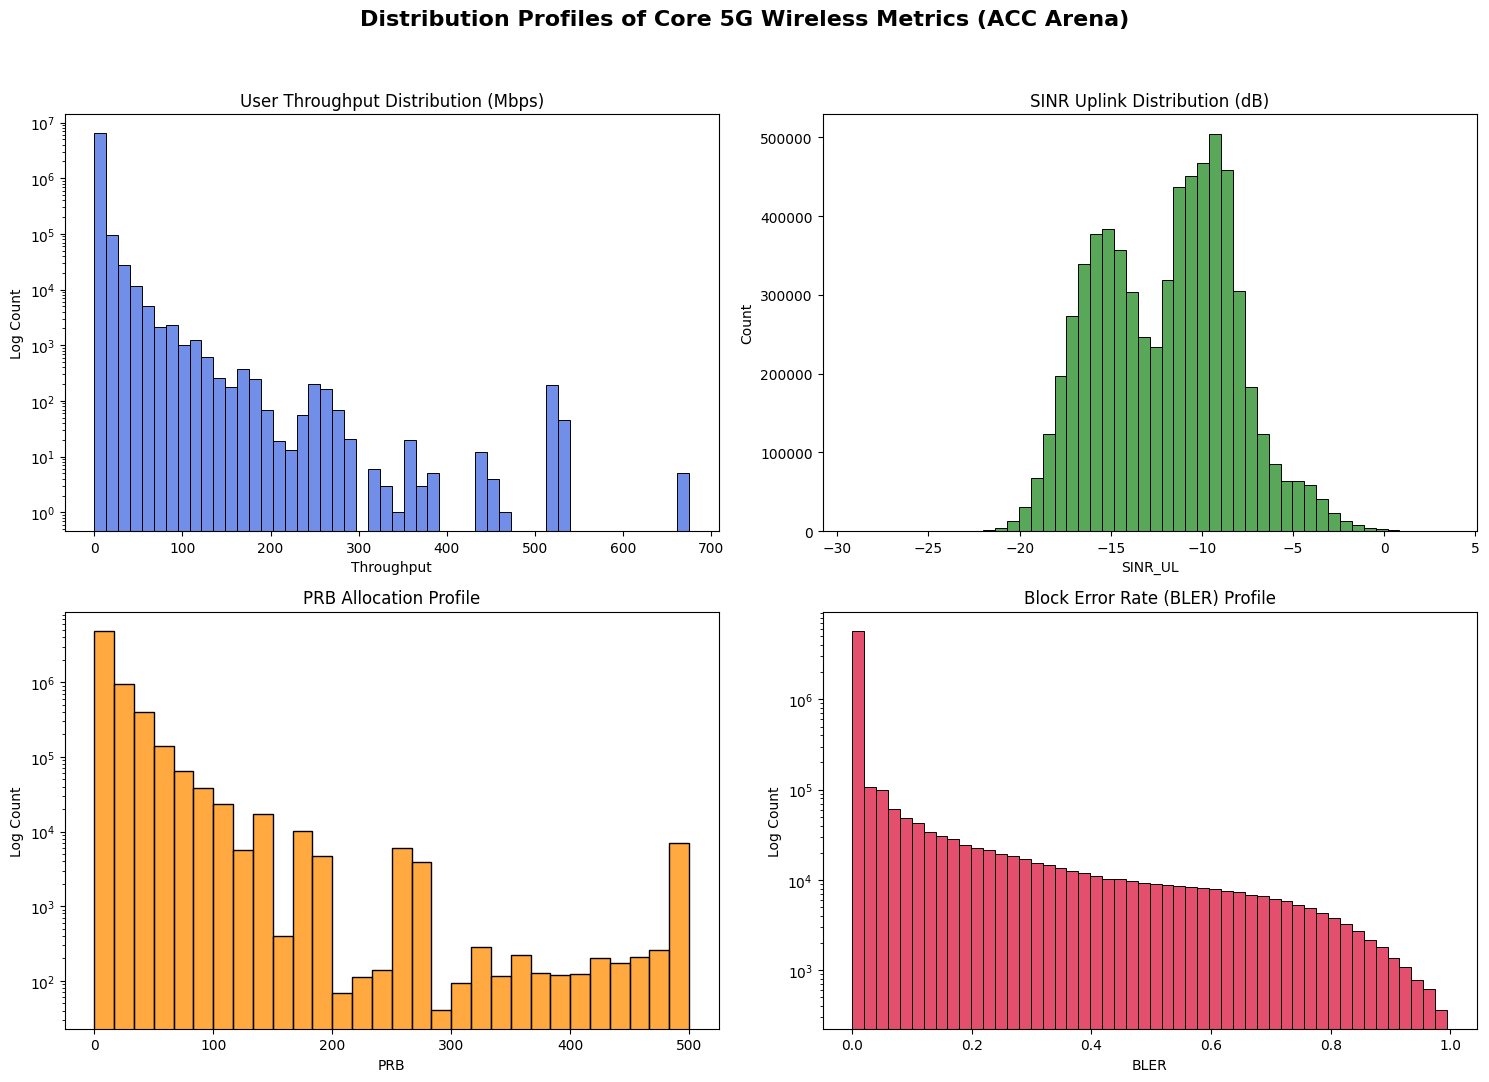

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Distribution Profiles of Core 5G Wireless Metrics (ACC Arena)', fontsize=16, fontweight='bold')

# Throughput Distribution
sns.histplot(data=master_df, x='Throughput', bins=50, ax=axes[0,0], color='royalblue', kde=False)
axes[0,0].set_title('User Throughput Distribution (Mbps)', fontsize=12)
axes[0,0].set_yscale('log') # Log scale prevents 0-value peaks from hiding everything else
axes[0,0].set_ylabel('Log Count')

# SINR Uplink Distribution
sns.histplot(data=master_df, x='SINR_UL', bins=50, ax=axes[0,1], color='forestgreen', kde=False)
axes[0,1].set_title('SINR Uplink Distribution (dB)', fontsize=12)
axes[0,1].set_ylabel('Count')

# Physical Resource Blocks (PRB) Distribution
sns.histplot(data=master_df, x='PRB', bins=30, ax=axes[1,0], color='darkorange', kde=False)
axes[1,0].set_title('PRB Allocation Profile', fontsize=12)
axes[1,0].set_yscale('log')
axes[1,0].set_ylabel('Log Count')

# Block Error Rate (BLER) Distribution
sns.histplot(data=master_df, x='BLER', bins=50, ax=axes[1,1], color='crimson', kde=False)
axes[1,1].set_title('Block Error Rate (BLER) Profile', fontsize=12)
axes[1,1].set_yscale('log')
axes[1,1].set_ylabel('Log Count')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

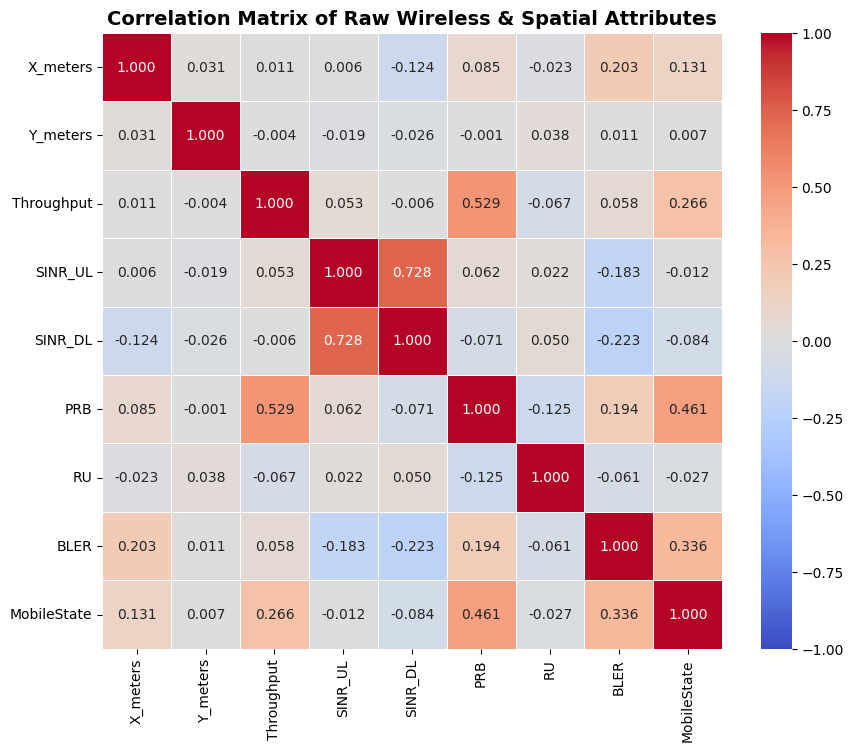

In [13]:
# Select the numeric attributes we want to check for patterns
corr_features = ['X_meters', 'Y_meters', 'Throughput', 'SINR_UL', 'SINR_DL', 'PRB', 'RU', 'BLER', 'MobileState']
corr_matrix = master_df[corr_features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Raw Wireless & Spatial Attributes', fontsize=14, fontweight='bold')
plt.show()


=== RADIO UNIT CONNECTION DISTRIBUTION ===
📡 Radio Unit 1: 51,527 connections (0.78%)
📡 Radio Unit 2: 170,848 connections (2.60%)
📡 Radio Unit 3: 239,363 connections (3.65%)
📡 Radio Unit 4: 43,746 connections (0.67%)
📡 Radio Unit 5: 92,134 connections (1.40%)
📡 Radio Unit 6: 290,885 connections (4.43%)
📡 Radio Unit 7: 59,642 connections (0.91%)
📡 Radio Unit 8: 29,800 connections (0.45%)
📡 Radio Unit 9: 276,762 connections (4.22%)
📡 Radio Unit 10: 22,081 connections (0.34%)
📡 Radio Unit 11: 154,019 connections (2.35%)
📡 Radio Unit 12: 226,799 connections (3.46%)
📡 Radio Unit 13: 70,583 connections (1.08%)
📡 Radio Unit 14: 40,604 connections (0.62%)
📡 Radio Unit 15: 289,208 connections (4.41%)
📡 Radio Unit 16: 93,250 connections (1.42%)
📡 Radio Unit 17: 44,586 connections (0.68%)
📡 Radio Unit 18: 303,971 connections (4.63%)
📡 Radio Unit 19: 212,999 connections (3.24%)
📡 Radio Unit 20: 83,778 connections (1.28%)
📡 Radio Unit 21: 191,770 connections (2.92%)
📡 Radio Unit 22: 319,094 connec

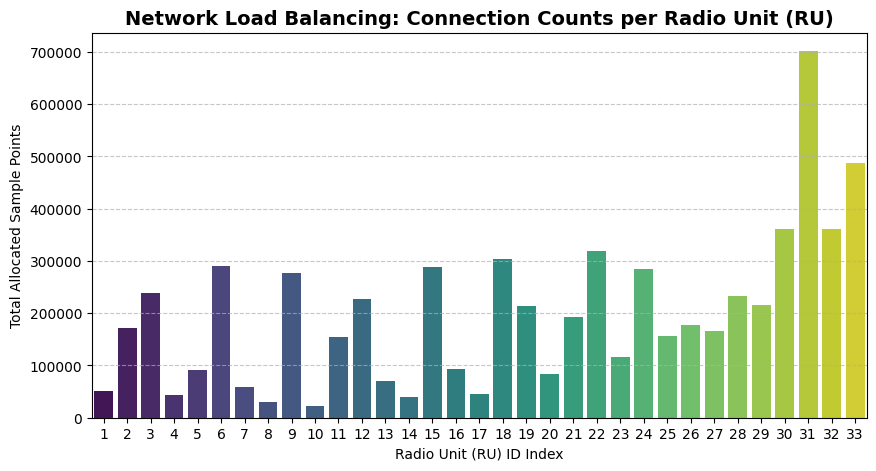

In [14]:
# 1. Count exactly how many records are connected to each individual Radio Unit
ru_counts = master_df['RU'].value_counts().sort_index()
ru_percentages = master_df['RU'].value_counts(normalize=True).sort_index() * 100

print("\n=== RADIO UNIT CONNECTION DISTRIBUTION ===")
for ru_id in ru_counts.index:
    print(f"📡 Radio Unit {ru_id}: {ru_counts[ru_id]:,} connections ({ru_percentages[ru_id]:.2f}%)")

# 2. Visualize the categorical load balancing using a Bar Chart
plt.figure(figsize=(10, 5))
sns.countplot(data=master_df, x='RU', palette='viridis')
plt.title('Network Load Balancing: Connection Counts per Radio Unit (RU)', fontsize=14, fontweight='bold')
plt.xlabel('Radio Unit (RU) ID Index')
plt.ylabel('Total Allocated Sample Points')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


=== TRAFFIC MIX COMPOSITION MATRIX ===
 0: Off             ->    11,444 rows (0.17%)
 1: Idle            -> 4,595,546 rows (70.01%)
 2: Constant Rate   -> 1,041,493 rows (15.87%)
 3: Video           ->    59,221 rows (0.90%)
 4: Gaming          ->    41,712 rows (0.64%)
 5: HTTP            ->   814,584 rows (12.41%)


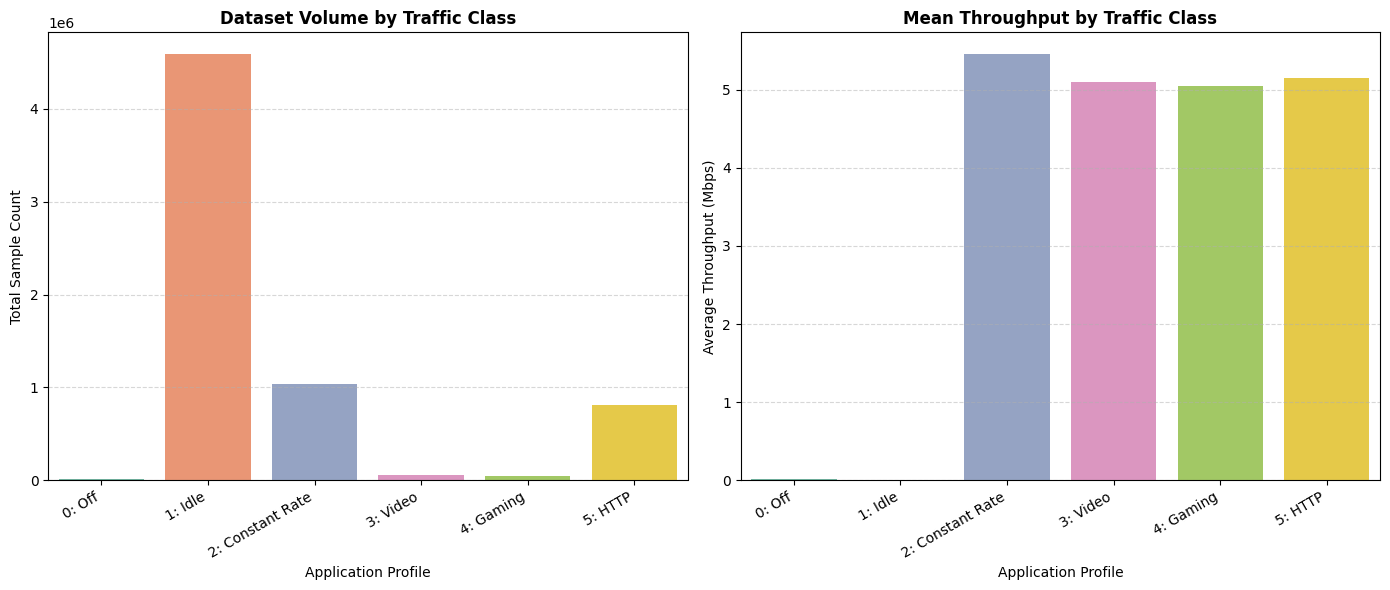

In [15]:
# 1. Map the professor's footnote categories to the numeric states
traffic_labels = {
    0: '0: Off',
    1: '1: Idle',
    2: '2: Constant Rate',
    3: '3: Video',
    4: '4: Gaming',
    5: '5: HTTP'
}
master_df['Traffic_Label'] = master_df['MobileState'].map(traffic_labels)

# 2. Print absolute composition metrics
traffic_counts = master_df['Traffic_Label'].value_counts().sort_index()
traffic_pct = master_df['Traffic_Label'].value_counts(normalize=True).sort_index() * 100

print("\n=== TRAFFIC MIX COMPOSITION MATRIX ===")
for label in traffic_counts.index:
    print(f" {label:<18} -> {traffic_counts[label]:>9,} rows ({traffic_pct[label]:.2f}%)")

# 3. Visualize Behavior: How does Traffic Class change Throughput?
plt.figure(figsize=(14, 6))

# Subplot 1: Volume of rows per traffic type
plt.subplot(1, 2, 1)
sns.countplot(data=master_df, x='Traffic_Label', palette='Set2', order=sorted(traffic_labels.values()))
plt.title('Dataset Volume by Traffic Class', fontsize=12, fontweight='bold')
plt.xlabel('Application Profile')
plt.ylabel('Total Sample Count')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Subplot 2: Average Throughput per traffic type
plt.subplot(1, 2, 2)
sns.barplot(data=master_df, x='Traffic_Label', y='Throughput', palette='Set2', order=sorted(traffic_labels.values()), errorbar=None)
plt.title('Mean Throughput by Traffic Class', fontsize=12, fontweight='bold')
plt.xlabel('Application Profile')
plt.ylabel('Average Throughput (Mbps)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

* **The Idle Dominance:** The network environment is heavily skewed by non-active background traffic, where **State 1 (Idle)** accounts for **18,348,571 rows (70.01% of total volume)**.
* **Active State Sparsity:** High-impact, bursty application states that heavily load physical resources—such as **State 3 (Video Streaming, 0.90%)** and **State 4 (Gaming, 0.64%)**—are deeply buried in noise.

In [16]:
master_df.head(50)

,Timestamp_Sec,User_ID,Latitude,Longitude,Altitude,X_meters,Y_meters,SINR_UL,SINR_DL,BLER,RU,MobileState,Throughput,PRB,SINR_UL_q90,BLER_q10,Traffic_Label
0,0,0,53.395084,-2.992707,3.581009,0.0,0.0,-14.772825,-14.135747,0.813364,26,2,8.352800,33.700001,-10.496062,0.428805,2: Constant Rate
1,60,0,53.395084,-2.992707,3.581009,0.0,0.0,-16.963371,-16.852478,0.743953,26,2,1.079200,37.150002,-12.073236,0.301559,2: Constant Rate
2,120,0,53.395084,-2.992707,3.581009,0.0,0.0,-14.323143,-13.703755,0.576724,26,2,1.148800,34.299999,-10.814339,0.002990,2: Constant Rate
3,180,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.458859,-10.417394,0.219680,26,2,1.289600,33.299999,-7.676000,0.000298,2: Constant Rate
4,240,0,53.395084,-2.992707,3.581009,0.0,0.0,-9.672252,-9.366496,0.204938,26,2,1.364800,35.150002,-8.087138,0.006283,2: Constant Rate
5,300,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.464019,-10.129985,0.189375,26,2,1.136800,29.450001,-7.572224,0.005700,2: Constant Rate
6,360,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.004877,-9.809793,0.165452,26,2,5.279200,34.000000,-7.312283,0.003596,2: Constant Rate
7,420,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.476074,-9.944695,0.255898,26,2,5.476000,37.000000,-8.217306,0.000459,2: Constant Rate
8,480,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.385905,-10.148302,0.220332,26,2,1.423200,36.750000,-7.763103,0.002366,2: Constant Rate
9,540,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.951180,-10.751991,0.182759,26,2,1.392000,36.299999,-8.140181,0.004695,2: Constant Rate


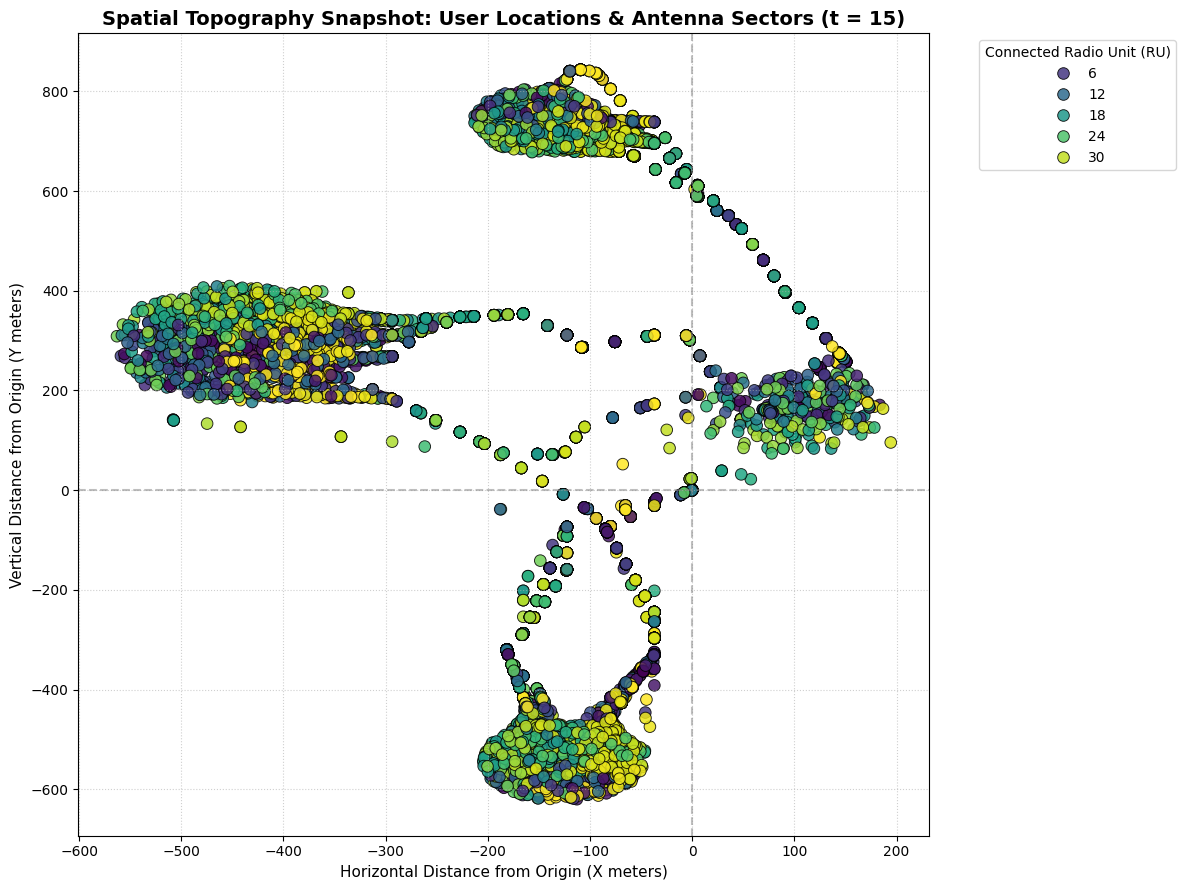

In [17]:
# 1. Isolate a single synchronized timestamp to view a clean spatial snapshot
# Timestamp 1215 contains all 500 active users tracked simultaneously
snapshot_df = master_df[master_df['Timestamp_Sec'] == 60]

# 2. Generate the spatial scatter plot
plt.figure(figsize=(12, 9))

# Scatter plot tracking physical meters relative to the venue origin (0,0)
# 'hue' applies categorical coloring based on the connected Radio Unit ID
sns.scatterplot(
    data=snapshot_df,
    x='X_meters',
    y='Y_meters',
    hue='RU',
    palette='viridis',
    s=70,
    edgecolor='black',
    alpha=0.85
)

# Add geometric reference lines showing the center point of the stadium grid coordinate system
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Formatting titles and axes labels
plt.title('Spatial Topography Snapshot: User Locations & Antenna Sectors (t = 15)', fontsize=14, fontweight='bold')
plt.xlabel('Horizontal Distance from Origin (X meters)', fontsize=11)
plt.ylabel('Vertical Distance from Origin (Y meters)', fontsize=11)

# Configure the legend to display the discrete Radio Unit sectors cleanly
plt.legend(title='Connected Radio Unit (RU)', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### **2.3: Feature Engineering**

## Feature Engineering

We construct physically‑motivated features from the aggregated 60‑second windows.  
The design follows four domains:

1. **Radio & Link Physics** – Convert SINR from dB to linear, then combine with BLER to form an **effective signal quality** metric.  
2. **Infrastructure Congestion** – Count how many users share the same Radio Unit at the same time (`RU_Current_Load`).  
3. **Temporal & Spatial Mobility** – Derive **velocity** from positional changes and compute **local crowd density** at three radii using a k‑d tree.  
4. **Application Behaviour** – One‑hot encode the `MobileState` to let the model learn traffic‑type‑specific patterns.

The resulting feature set is intentionally **non‑leaky**: we exclude raw `PRB` and its derived `Resource_Efficiency` from the main experiments because they act as a scheduling proxy for throughput (proved in a later ablation).

In [18]:
def engineer_acc_arena_features(df):
    """
    Executes advanced multi-domain feature engineering for the ACC Arena dataset.
    Optimized for memory efficiency and handles dynamic user dropouts safely.
    """
    print("Initiating Advanced Feature Engineering Pipeline...")
    feat_df = df.copy()

    # Identify correct time column based on our previous timeline fixes
    time_col = 'Timestamp_Sec' if 'Timestamp_Sec' in feat_df.columns else 'Timestamp'

    # CRITICAL: Sort by User_ID first to ensure perfect trajectory math
    feat_df = feat_df.sort_values(by=['User_ID', time_col]).reset_index(drop=True)

    # ----------------------------------------------------
    # DOMAIN 1: RADIO & LINK PHYSICS
    # ----------------------------------------------------
    print(" Engineering Radio Domain features...")
    print(" Regressing the max throughput...")

    # >0.9 linearity with SINR_UL
    feat_df.drop(columns=["SINR_DL"], inplace=True)

    # 4. Generate the Physics-Informed Robust Signal Feature
    feat_df['SINR_Linear_q90'] = (10 ** (feat_df['SINR_UL_q90'] / 10.0)).astype(np.float32)
    
    feat_df['Effective_Signal_Robust'] = np.clip(
        feat_df['SINR_Linear_q90'] / (feat_df['BLER_q10'] + 1e-4), 0, 1e6
    ).astype(np.float32)
    
    feat_df['Log_Effective_Signal_Robust'] = np.log1p(
        feat_df['Effective_Signal_Robust']
    ).astype(np.float32)

    # ----------------------------------------------------
    # DOMAIN 2: INFRASTRUCTURE CONGESTION
    # ----------------------------------------------------
    print(" Calculating Real-Time Radio Unit Load...")
    feat_df['RU_Current_Load'] = feat_df.groupby([time_col, 'RU'])['User_ID'].transform('count').astype(np.int16)

    # ----------------------------------------------------
    # DOMAIN 3: TEMPORAL & SPATIAL MOBILITY
    # ----------------------------------------------------
    print(" Computing Kinematic Vectors...")
    # 1215 subtraction removed: Timeline is already correctly zero-based!
    
    user_groups = feat_df.groupby('User_ID')
    feat_df['Delta_X'] = user_groups['X_meters'].diff().fillna(0).astype(np.float32)
    feat_df['Delta_Y'] = user_groups['Y_meters'].diff().fillna(0).astype(np.float32)
    feat_df['Velocity'] = np.sqrt(feat_df['Delta_X']**2 + feat_df['Delta_Y']**2).astype(np.float32)

    print(" Vectorizing Multi-Scale Local Crowd Density (cKDTree)...")
    radii = [2.0, 5.0, 10.0]
    density_results = {r: np.zeros(len(feat_df), dtype=np.int16) for r in radii}

    grouped_time = feat_df.groupby(time_col)
    
    # cKDTree easily handles missing users without crashing
    for t, group in tqdm(grouped_time, desc="Mapping Densities"):
        coords = group[['X_meters', 'Y_meters']].values
        tree = cKDTree(coords)
        for r in radii:
            counts = np.array([len(neighbors) - 1 for neighbors in tree.query_ball_point(coords, r)])
            density_results[r][group.index] = counts

    feat_df['Crowd_Density_2m'] = density_results[2.0]
    feat_df['Crowd_Density_5m'] = density_results[5.0]
    feat_df['Crowd_Density_10m'] = density_results[10.0]

    # ----------------------------------------------------
    # DOMAIN 4: APPLICATION BEHAVIOR
    # ----------------------------------------------------
    print(" Decoding Application States...")
    state_dummies = pd.get_dummies(feat_df['MobileState'], prefix='State').astype(np.int8)
    feat_df = pd.concat([feat_df, state_dummies], axis=1)

    feat_df['Resource_Efficiency'] = (feat_df['PRB'] * (feat_df['MobileState'] != 1)).astype(np.float32)

    # ----------------------------------------------------
    # MEMORY & INTEGRITY AUDIT
    # ----------------------------------------------------
    print("\n Finalizing Memory Cleanup Audit...")
    feat_df.drop(columns=['Delta_X', 'Delta_Y'], inplace=True)

    final_mem = feat_df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f" Engineering Complete! Dataframe Shape: {feat_df.shape}")
    print(f" Memory Footprint: {final_mem:.2f} MB")

    return feat_df

In [19]:
if os.path.exists(cached_feat):
    print("Loading processed cache...")
    arena_featured_df = pd.read_parquet(cached_feat)
elif os.path.exists(ds_feat):
    print("Loading processed from input ds...")
    arena_featured_df = pd.read_parquet(ds_feat)
else:
    print("No checkpoint found. Running feature engineering...")
    arena_featured_df = engineer_acc_arena_features(master_df)
    arena_featured_df.to_parquet(cached_feat, index=False)
    print("Checkpoint saved.")

Loading processed from input ds...


In [20]:
arena_featured_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6564000 entries, 0 to 6563999
Data columns (total 31 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Timestamp_Sec                int64  
 1   User_ID                      int32  
 2   Latitude                     float32
 3   Longitude                    float32
 4   Altitude                     float32
 5   X_meters                     float32
 6   Y_meters                     float32
 7   SINR_UL                      float32
 8   BLER                         float32
 9   RU                           int8   
 10  MobileState                  int8   
 11  Throughput                   float32
 12  PRB                          float32
 13  SINR_UL_q90                  float32
 14  BLER_q10                     float32
 15  Traffic_Label                object 
 16  SINR_Linear_q90              float32
 17  Effective_Signal_Robust      float32
 18  Log_Effective_Signal_Robust  float32
 19  

In [21]:
arena_featured_df.head(30)

,Timestamp_Sec,User_ID,Latitude,Longitude,Altitude,X_meters,Y_meters,SINR_UL,BLER,RU,...,Crowd_Density_2m,Crowd_Density_5m,Crowd_Density_10m,State_0,State_1,State_2,State_3,State_4,State_5,Resource_Efficiency
0,0,0,53.395084,-2.992707,3.581009,0.0,0.0,-14.772825,0.813364,26,...,35,35,46,0,0,1,0,0,0,33.700001
1,60,0,53.395084,-2.992707,3.581009,0.0,0.0,-16.963371,0.743953,26,...,35,35,46,0,0,1,0,0,0,37.150002
2,120,0,53.395084,-2.992707,3.581009,0.0,0.0,-14.323143,0.576724,26,...,35,35,46,0,0,1,0,0,0,34.299999
3,180,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.458859,0.219680,26,...,35,35,46,0,0,1,0,0,0,33.299999
4,240,0,53.395084,-2.992707,3.581009,0.0,0.0,-9.672252,0.204938,26,...,35,35,46,0,0,1,0,0,0,35.150002
5,300,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.464019,0.189375,26,...,35,35,46,0,0,1,0,0,0,29.450001
6,360,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.004877,0.165452,26,...,35,35,46,0,0,1,0,0,0,34.000000
7,420,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.476074,0.255898,26,...,35,35,46,0,0,1,0,0,0,37.000000
8,480,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.385905,0.220332,26,...,35,35,46,0,0,1,0,0,0,36.750000
9,540,0,53.395084,-2.992707,3.581009,0.0,0.0,-10.951180,0.182759,26,...,35,35,46,0,0,1,0,0,0,36.299999


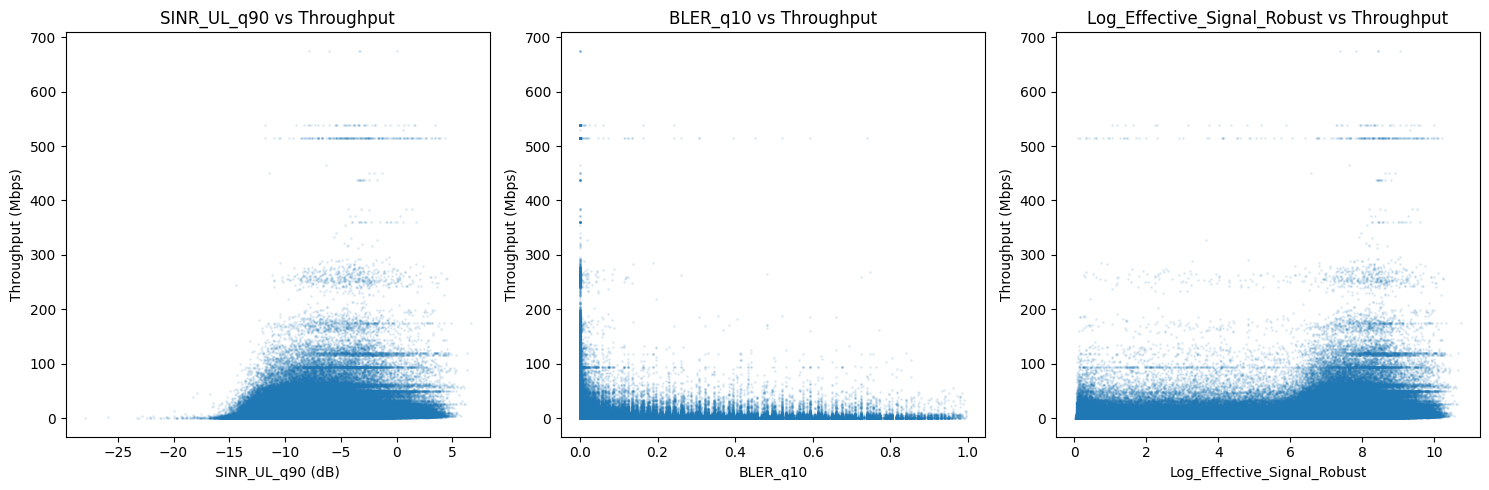

In [22]:
# ════════════════════════════════════════════════════════════════
# SECTION 2 — EDA DIAGNOSTICS (visual only, feeds no decision)
# ════════════════════════════════════════════════════════════════
active_df = arena_featured_df[arena_featured_df['Throughput'] > 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(active_df['SINR_UL_q90'], active_df['Throughput'], alpha=0.1, s=1)
axes[0].set_xlabel('SINR_UL_q90 (dB)'); axes[0].set_ylabel('Throughput (Mbps)')
axes[0].set_title('SINR_UL_q90 vs Throughput')

axes[1].scatter(active_df['BLER_q10'], active_df['Throughput'], alpha=0.1, s=1)
axes[1].set_xlabel('BLER_q10'); axes[1].set_ylabel('Throughput (Mbps)')
axes[1].set_title('BLER_q10 vs Throughput')

axes[2].scatter(active_df['Log_Effective_Signal_Robust'], active_df['Throughput'], alpha=0.1, s=1)
axes[2].set_xlabel('Log_Effective_Signal_Robust'); axes[2].set_ylabel('Throughput (Mbps)')
axes[2].set_title('Log_Effective_Signal_Robust vs Throughput')

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# Hard physical sanity filters
# ============================================================
before = len(arena_featured_df)

arena_featured_df = arena_featured_df[
    (arena_featured_df['Throughput'] >= 0) &
    (arena_featured_df['BLER'].between(0, 1)) &
    (arena_featured_df['BLER_q10'].between(0, 1)) &
    (arena_featured_df['SINR_UL'].between(-40, 30)) &
    (arena_featured_df['SINR_UL_q90'].between(-40, 30))
].copy()

after = len(arena_featured_df)
print(f"Removed {before - after:,} physically invalid rows")

spike = arena_featured_df[arena_featured_df['Throughput'] > 500]
print(spike['Throughput'].value_counts().head(20))

display(
    spike.groupby(['RU'])['Throughput']
         .agg(['count', 'mean', 'min', 'max'])
         .sort_values('count', ascending=False)
         .head(20)
)

Removed 0 physically invalid rows
Throughput
515.056030    124
514.104004     66
539.070374     26
538.849609     12
513.935974      5
538.118408      4
673.900818      4
537.897583      2
529.910400      1
675.151978      1
Name: count, dtype: int64


,count,mean,min,max
RU,,,,
10,56,520.356079,514.104004,539.070374
1,38,518.272217,513.935974,539.070374
8,31,520.857971,513.935974,539.070374
13,22,518.017761,514.104004,539.070374
14,21,539.144287,514.104004,675.151978
4,17,534.919312,514.104004,673.900818
20,13,516.537109,514.104004,539.070374
17,11,518.954163,513.935974,539.070374
16,10,530.654907,514.104004,673.900818


In [24]:
high_tp = active_df['Throughput'] >= active_df['Throughput'].quantile(0.99)
low_tp = active_df['Throughput'] <= active_df['Throughput'].quantile(0.10)

high_signal = active_df['Log_Effective_Signal_Robust'] >= active_df['Log_Effective_Signal_Robust'].quantile(0.90)
low_signal  = active_df['Log_Effective_Signal_Robust'] <= active_df['Log_Effective_Signal_Robust'].quantile(0.10)

active_df['Anomaly_Type'] = 'normal'
active_df.loc[high_tp & low_signal, 'Anomaly_Type'] = 'high_tp_bad_signal'
active_df.loc[low_tp & high_signal, 'Anomaly_Type'] = 'low_tp_good_signal'

In [25]:
# ============================================================
# Feature definition: non-leaky, non-redundant
# ============================================================
target = 'Throughput'

crowd_density = ['Crowd_Density_2m','Crowd_Density_5m','Crowd_Density_10m']

state_cols = [c for c in arena_featured_df.columns if c.startswith('State_')]

base_feats = [
    'X_meters', 'Y_meters',
    'SINR_UL','SINR_UL_q90', 'BLER','BLER_q10', 
    'RU_Current_Load', 'Velocity', 'Log_Effective_Signal_Robust'
] + [crowd_density[1]] + state_cols

# Keep only columns that actually exist
base_feats = [c for c in base_feats if c in arena_featured_df.columns]

# Safety check: drop globally constant / near-constant features
def remove_constant_features(df, cols, threshold=1e-6):
    kept, dropped = [], []
    for c in cols:
        if c in df.columns and df[c].std(skipna=True) > threshold:
            kept.append(c)
        else:
            dropped.append(c)
    if dropped:
        print("Dropped near-constant features:", dropped)
    return kept

base_feats = remove_constant_features(arena_featured_df, base_feats)

In [26]:
arena_featured_df.drop(columns=['Effective_Signal_Robust'], inplace=True) 
if not (arena_featured_df['Velocity'].notna().mean() > 0.95 and arena_featured_df['Velocity'].nunique() > 1):
    print("Velocity not added to features (constant or mostly NaN).")
    arena_featured_df.drop(columns=['Velocity'], inplace=True)

In [27]:
# manual separation dynamics and static, should be based on global activity dynamic
dynamic_cols = [
    'SINR_UL',
    'BLER',
    'SINR_UL_q90',
    'BLER_q10',
    'Log_Effective_Signal_Robust',
    'RU_Current_Load',
    'X_meters',
    'Y_meters',
    'Velocity',
] + [crowd_density[1]]

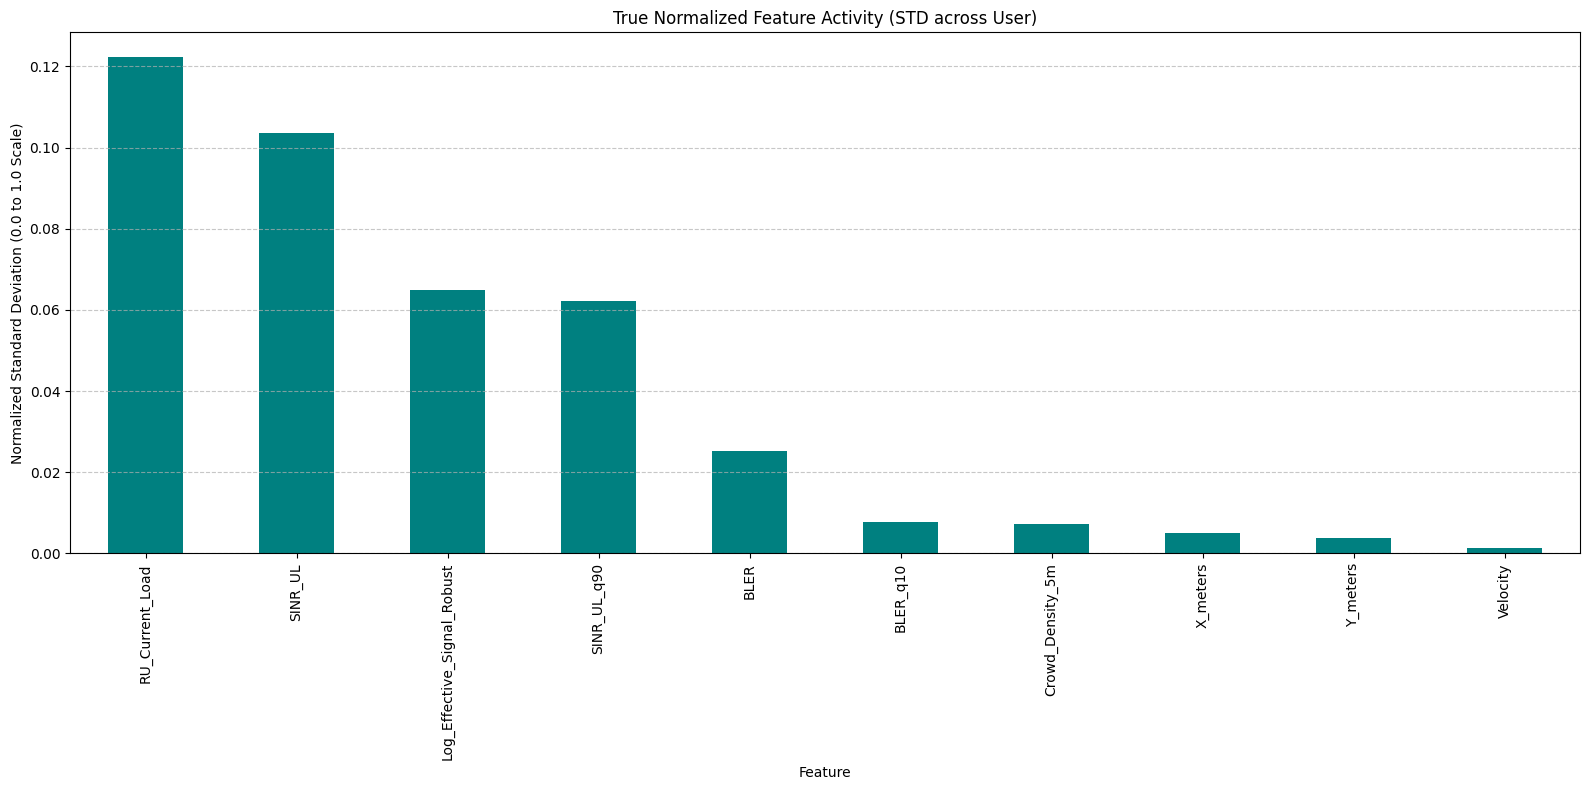

In [28]:
# Step 1: Create a temporary dataframe scaled between 0 and 1 for fair comparison
df_scaled = arena_featured_df[dynamic_cols].copy()
for col in dynamic_cols:
    col_min = df_scaled[col].min()
    col_max = df_scaled[col].max()
    if col_max - col_min > 0:
        df_scaled[col] = (df_scaled[col] - col_min) / (col_max - col_min)

# Step 2: Compute average activity on the normalized scale
# Using the User_ID from the original master dataframe to group
activity = (
    df_scaled.groupby(arena_featured_df["User_ID"])
    .std()      # Variance relative to each feature's own min/max limits
    .mean()     # Average across all 500 users
    .sort_values(ascending=False)
)

# # Step 3: Render the corrected true activity distribution
plt.figure(figsize=(16, 8))
activity.plot(kind='bar', title='True Normalized Feature Activity (STD across User)', color='teal', rot=90)
plt.xlabel('Feature')
plt.ylabel('Normalized Standard Deviation (0.0 to 1.0 Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Dynamic vs. Static Feature Decomposition

To separate time‑varying (dynamic) from time‑constant (static) features, we compute the **per‑user standard deviation** of each candidate dynamic feature.  
A feature is retained as dynamic only if its mean user‑level STD exceeds a small threshold, indicating genuine temporal variation.  
This step ensures that our LSTM receives meaningful sequences, while static features (e.g., traffic state dummies) are fed only to the MLP branch as context.

In [29]:
dyn_threshold = 1e-4
dynamic_cols = [c for c in dynamic_cols if c in base_feats and activity[c] > dyn_threshold]

static_cols = [c for c in state_cols if c in base_feats]

print("BASE_FEATS:", base_feats)
print("dynamic_cols:", dynamic_cols)
print("static_cols:", static_cols)

BASE_FEATS: ['X_meters', 'Y_meters', 'SINR_UL', 'SINR_UL_q90', 'BLER', 'BLER_q10', 'RU_Current_Load', 'Velocity', 'Log_Effective_Signal_Robust', 'Crowd_Density_5m', 'State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']
dynamic_cols: ['SINR_UL', 'BLER', 'SINR_UL_q90', 'BLER_q10', 'Log_Effective_Signal_Robust', 'RU_Current_Load', 'X_meters', 'Y_meters', 'Velocity', 'Crowd_Density_5m']
static_cols: ['State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']


In [30]:
use_lag = False

In [31]:
# ────────────────────────────────────────────────────────────────
# CLEAN FEATURE DEFINITIONS
# ────────────────────────────────────────────────────────────────
df = arena_featured_df.copy()
lagged_feat = activity.head(4).index.tolist()
newly_generated_lag_cols = []

if use_lag:
  LAGS = [5, 10]
  user_ids = df['User_ID'].values
  print("generating new lagged features...")
  # Generate lagged features and update TRAIN_FEATS with their names
  # for col in train_feats_base:
  for col in lagged_feat:
      arr = df[col]
      for lag in LAGS:
        new_col = f'{col}_lag{lag}'
        shifted = np.full(len(df), np.nan, dtype=np.float32)
        shifted[lag:] = arr[:-lag]
        invalid = np.zeros(len(df), dtype=bool)
        invalid[lag:] = (user_ids[lag:] != user_ids[:-lag])
        shifted[invalid] = np.nan
        df[new_col] = shifted
        newly_generated_lag_cols.append(new_col)
    
    # Quick check: manual shift just to check correlation with your target variable
  for col in newly_generated_lag_cols:
    corr = df[col].corr(df[target])
    print(f"{col} Lag Corr with Target: {corr:.4f}")

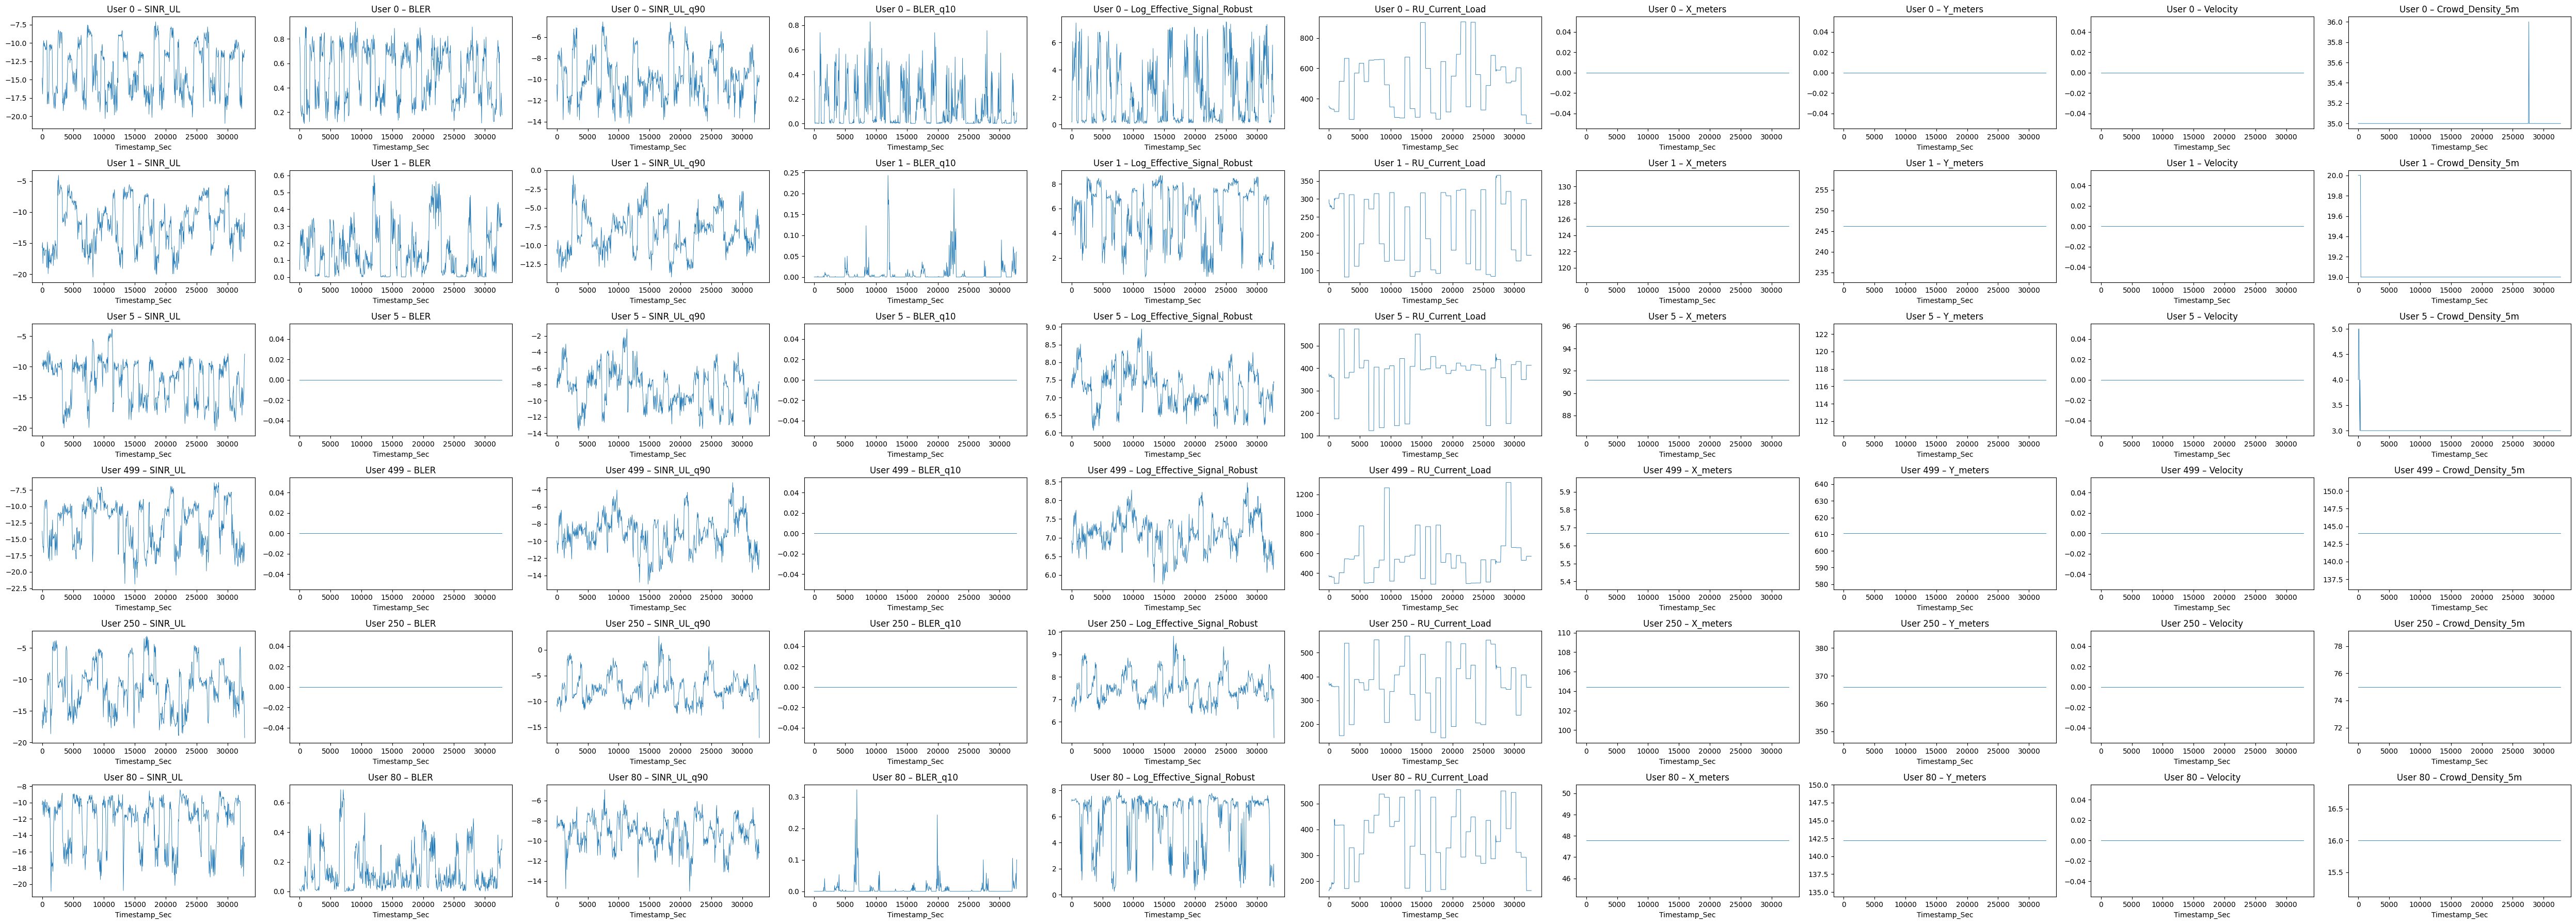

In [32]:
sample_users = [0, 1, 5, 499, 250, 80]  # pick any three existing User_IDs

features_to_plot = dynamic_cols

fig, axes = plt.subplots(len(sample_users), len(features_to_plot),
                         figsize=(5*len(features_to_plot), 3*len(sample_users)))
for i, uid in enumerate(sample_users):
    u = df[df['User_ID'] == uid].sort_values('Timestamp_Sec')
    for j, feat in enumerate(features_to_plot):
        ax = axes[i, j] if len(sample_users)>1 else axes[j]
        ax.plot(u['Timestamp_Sec'], u[feat], linewidth=0.6)
        ax.set_title(f'User {uid} – {feat}')
        ax.set_xlabel('Timestamp_Sec')
plt.tight_layout()
plt.show()

In [33]:
df['Has_Throughput'] = (df[target] > 0).astype(np.int8)
active_ratio = df['Has_Throughput'].mean()
print(f"Active (throughput > 0): {active_ratio*100:.1f}%  |  Idle: {(1-active_ratio)*100:.1f}%")

Active (throughput > 0): 29.9%  |  Idle: 70.1%


## User‑Level Data Split

We split by **User_ID**, not by random rows.  
- **Train + Validation**: 10,000 users (80 %/20 % stratified by user)  
- **Test**: 2,000 completely unseen users

This prevents the model from memorising user‑specific patterns and ensures that the evaluation truly measures generalisation to new devices.  
We do **not** undersample the dataset; the LSTM+MLP pipeline uses the natural class distribution for realistic training.

In [34]:
def train_test_split(df, test_id_start=10000, val_frac=0.20, random_seed=42, is_undersampling=False):
    if (max_user_id == 1499):
        test_id_start = 1200
    # 1. Split out test set (last 800 users)
    test_df = df[df['User_ID'] >= test_id_start].copy()
    train_val_df = df[df['User_ID'] < test_id_start].copy()
    
    # 2. Get unique users from train_val and shuffle
    unique_users = train_val_df['User_ID'].unique().tolist()
    random.seed(random_seed)
    random.shuffle(unique_users)
    
    val_size = int(len(unique_users) * val_frac)
    val_users = set(unique_users[:val_size])
    train_users = set(unique_users[val_size:])

    # 3. Create training and validation DataFrames
    train_df = train_val_df[train_val_df['User_ID'].isin(train_users)].copy()
    val_df = train_val_df[train_val_df['User_ID'].isin(val_users)].copy()

    if is_undersampling:
        print("2. Undersampling the Training Data...")
        # Separate the classes INSIDE the training set only
        idle_rows = train_df[train_df['Has_Throughput'] == 0]
        active_rows = train_df[train_df['Has_Throughput'] != 0]
        
        # Undersample the Idle class to perfectly match the active traffic volume (1:1 balance)
        sampled_idle = idle_rows.sample(n=len(active_rows), random_state=random_seed)
        
        # Combine and Shuffle to create the final balanced training set
        train_df = pd.concat([active_rows, sampled_idle], axis=0).sample(frac=1, random_state=random_seed).reset_index(drop=True)
        print(f"✅ New Balanced Training Shape: {train_df.shape}")
        print(f"✅ Untouched Validation Shape: {val_df.shape}")

    print(f"  Test users:   {len(test_df['User_ID'].unique())} → {len(test_df):,} rows")
    print(f"  Train users:  {len(train_users)} → {len(train_df):,} rows")
    print(f"  Val users:    {len(val_users)}   → {len(val_df):,} rows")
    return train_df, val_df, test_df

In [35]:
print("\n=== TRAIN, VAL/ TEST SPLIT ===")
# don't undersample for training the LSTM + MLP static
train_df, val_df, test_df = train_test_split(df, is_undersampling=False)


=== TRAIN, VAL/ TEST SPLIT ===
  Test users:   2000 → 1,094,000 rows
  Train users:  8000 → 4,376,000 rows
  Val users:    2000   → 1,094,000 rows


In [36]:
# after undersampling: count rows per user
full_counts = train_df.groupby('User_ID').size()
print(full_counts.describe())
print(f"Unique timestep counts: {full_counts.nunique()}")

count    8000.0
mean      547.0
std         0.0
min       547.0
25%       547.0
50%       547.0
75%       547.0
max       547.0
dtype: float64
Unique timestep counts: 1


In [37]:
# Compute fill values from training set ONLY
fill_vals = train_df.mean(numeric_only=True)

train_df.fillna(fill_vals, inplace=True)
val_df.fillna(fill_vals, inplace=True)
test_df.fillna(fill_vals, inplace=True)

In [38]:
train_pos = train_df[train_df['Has_Throughput'] == 1].copy()
val_pos = val_df[val_df['Has_Throughput'] == 1].copy()
test_pos  = test_df[test_df['Has_Throughput']  == 1].copy()
print(f"Train active rows: {len(train_pos):,}| Val active rows: {len(val_pos):,} | Test active rows: {len(test_pos):,}")

Train active rows: 1,392,756| Val active rows: 377,766 | Test active rows: 188,845


In [39]:
# ── Logging config — toggle these freely ──
LOG_CV_VERBOSE    = 3     # 0=silent, 1=time only, 2=score per fold, 3=fold+size
LOG_EPOCH_VERBOSE = True  # DNN epoch-by-epoch loss (final fit only, not during CV)
LOG_RF_TREES      = 1     # RF tree-building progress (0=silent, 1=parallel progress)
RANDOM_STATE = 42
ACTIVE_THRESHOLD = 0.5
SAMPLE_N_S1 = 800_000
SAMPLE_N_S2 = 500_000
N_ESTIMATOR = 100
MAX_DEPTH = 20

In [40]:
def existing_cols(df, cols):
    return [c for c in cols if c in df.columns]

In [41]:
leaky_cols     = ['PRB', 'Resource_Efficiency']
state_cols = [c for c in train_df.columns if c.startswith("State_")]
mean_only_cols = ['SINR_UL', 'BLER', 'X_meters', 'Y_meters', 'RU_Current_Load', 'Velocity'] + [crowd_density[1]]
peak_cols      = ['SINR_UL_q90', 'BLER_q10', 'Log_Effective_Signal_Robust']

feature_sets = {
    "D_peak_lagged_non_leaky": existing_cols(train_df, mean_only_cols + peak_cols + state_cols),
}

if any(c in train_df.columns for c in leaky_cols):
    feature_sets["A_leaky_upper_bound"] = existing_cols(
        train_df, mean_only_cols + peak_cols + leaky_cols + state_cols
    )

print("Feature sets:")
for name, feats in feature_sets.items():
    print(f"\n{name}: {len(feats)} features\n{feats}")

Feature sets:

D_peak_lagged_non_leaky: 16 features
['SINR_UL', 'BLER', 'X_meters', 'Y_meters', 'RU_Current_Load', 'Velocity', 'Crowd_Density_5m', 'SINR_UL_q90', 'BLER_q10', 'Log_Effective_Signal_Robust', 'State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']

A_leaky_upper_bound: 18 features
['SINR_UL', 'BLER', 'X_meters', 'Y_meters', 'RU_Current_Load', 'Velocity', 'Crowd_Density_5m', 'SINR_UL_q90', 'BLER_q10', 'Log_Effective_Signal_Robust', 'PRB', 'Resource_Efficiency', 'State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']


In [42]:
# =====================================================================
# 1. CONFIGURATION & DETERMINISM
# =====================================================================
@dataclass
class ExperimentConfig:
    random_state: int = 42
    active_threshold: float = 0.5
    n_estimators: int = 100
    max_depth: int = 20
    use_gpu_rf: bool = False
    rf_n_streams: int = 8
    sample_n_s1: Optional[int] = None
    sample_n_s2: Optional[int] = None

    seq_len: int = 16
    stride: int = 4
    batch_size: int = 256
    lstm_hidden: int = 32
    mlp_hidden: int = 16
    fusion_hidden: int = 32
    num_layers: int = 1
    dropout: float = 0.20
    epochs: int = 20
    patience: int = 4
    lr: float = 1e-3
    weight_decay: float = 1e-5
    meta_frac: float = 0.20

CFG = ExperimentConfig(use_gpu_rf=HAS_CUML)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("cuML RF available:", HAS_CUML)

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Force PyTorch Determinism to stop metric drift
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_everything(CFG.random_state)

def to_numpy_safe(x):
    if cp is not None:
        try:
            if isinstance(x, cp.ndarray):
                return cp.asnumpy(x)
        except Exception:
            pass
    return x.to_numpy() if hasattr(x, "to_numpy") else np.asarray(x)

def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))

# =====================================================================
# 2. METRICS & VISUALIZATION HELPERS
# =====================================================================
def get_metrics(y_true_raw: np.ndarray, y_pred_raw: np.ndarray) -> Dict[str, float]:
    y_true_raw = np.asarray(y_true_raw, dtype=np.float32)
    y_pred_raw = np.clip(np.asarray(y_pred_raw, dtype=np.float32), 0, None)
    y_true_log = np.log1p(y_true_raw)
    y_pred_log = np.log1p(y_pred_raw)
    return {
        "R2_log": r2_score(y_true_log, y_pred_log),
        "RMSE_log": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "MAE_log": mean_absolute_error(y_true_log, y_pred_log),
        "R2_raw": r2_score(y_true_raw, y_pred_raw),
        "RMSE_raw": np.sqrt(mean_squared_error(y_true_raw, y_pred_raw)),
        "MAE_raw": mean_absolute_error(y_true_raw, y_pred_raw),
    }

def print_metric_table(results: Dict[str, Dict[str, float]]) -> pd.DataFrame:
    order = ["R2_log", "RMSE_log", "MAE_log", "R2_raw", "RMSE_raw", "MAE_raw"]
    result_df = pd.DataFrame(results).T[order]
    display(result_df)
    return result_df

def plot_final_comparison(result_df: pd.DataFrame, path: Optional[str] = None) -> None:
    fig, ax = plt.subplots(figsize=(12, 6))
    values = result_df["R2_log"].values
    colors = ['#1f77b4' if 'Central' in idx else '#ff7f0e' if 'VFL' in idx else '#2ca02c' for idx in result_df.index]
    
    bars = ax.bar(result_df.index, values, color=colors, edgecolor='black')
    ax.set_title("Sequence-Aligned Test R² (Log Throughput) - Full Baseline Showdown", fontsize=14, fontweight='bold')
    ax.set_ylabel("R² log Score")
    ax.set_ylim(0, 1.0)
    
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.xticks(rotation=25, ha="right", fontsize=10)
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=300)
    plt.show()

def sort_for_sequence(df: pd.DataFrame, user_col: str = "User_ID", time_col: str = "Timestamp_Sec") -> pd.DataFrame:
    if time_col in df.columns:
        return df.sort_values([user_col, time_col]).reset_index(drop=True)
    return df.sort_values([user_col]).reset_index(drop=True)

# =====================================================================
# 3. RANDOM FOREST ENGINE
# =====================================================================
# =====================================================================
# 3. RANDOM FOREST ENGINE (WITH WAITABLE PRINTS)
# =====================================================================
def sample_xy(X: np.ndarray, y: np.ndarray, sample_n: Optional[int], seed: int) -> Tuple[np.ndarray, np.ndarray]:
    if sample_n is None or len(X) <= sample_n:
        return X, y
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=sample_n, replace=False)
    return X[idx], y[idx]

def train_rf_classifier(X: np.ndarray, y: np.ndarray, cfg: ExperimentConfig = CFG):
    X_fit, y_fit = sample_xy(X, y, cfg.sample_n_s1, cfg.random_state)
    mode = "FULL DATASET" if cfg.sample_n_s1 is None else f"SUBSAMPLE ({cfg.sample_n_s1:,})"
    print(f"   [⌛] Fitting Stage 1 Classifier on {mode}: {len(X_fit):,} rows... (Please wait)")
    start_time = time.time()
    
    if cfg.use_gpu_rf and HAS_CUML:
        model = cuRFClassifier(n_estimators=cfg.n_estimators, max_depth=cfg.max_depth, random_state=cfg.random_state, n_streams=cfg.rf_n_streams)
        model.fit(cp.asarray(X_fit.astype(np.float32)), cp.asarray(y_fit.astype(np.int32)))
        backend = "gpu_cuml"
    else:
        model = RandomForestClassifier(n_estimators=cfg.n_estimators, max_depth=cfg.max_depth, n_jobs=-1, random_state=cfg.random_state, class_weight="balanced")
        model.fit(X_fit, y_fit)
        backend = "cpu_sklearn"
        
    print(f"   [✅] Stage 1 Classifier complete in {time.time() - start_time:.1f} seconds.")
    clear_memory()
    return model, backend

def train_rf_regressor(X: np.ndarray, y_log: np.ndarray, cfg: ExperimentConfig = CFG):
    X_fit, y_fit = sample_xy(X, y_log, cfg.sample_n_s2, cfg.random_state)
    mode = "FULL DATASET" if cfg.sample_n_s2 is None else f"SUBSAMPLE ({cfg.sample_n_s2:,})"
    print(f"   [⌛] Fitting Stage 2 Regressor on {mode}: {len(X_fit):,} rows... (Please wait)")
    start_time = time.time()
    
    if cfg.use_gpu_rf and HAS_CUML:
        model = cuRFRegressor(n_estimators=cfg.n_estimators, max_depth=cfg.max_depth, random_state=cfg.random_state, n_streams=cfg.rf_n_streams)
        model.fit(cp.asarray(X_fit.astype(np.float32)), cp.asarray(y_fit.astype(np.float32)))
        backend = "gpu_cuml"
    else:
        model = RandomForestRegressor(n_estimators=cfg.n_estimators, max_depth=cfg.max_depth, n_jobs=-1, random_state=cfg.random_state)
        model.fit(X_fit, y_fit)
        backend = "cpu_sklearn"
        
    print(f"   [✅] Stage 2 Regressor complete in {time.time() - start_time:.1f} seconds.")
    clear_memory()
    return model, backend

def predict_rf(model, backend: str, X: np.ndarray) -> np.ndarray:
    X = X.astype(np.float32)
    if "gpu" in backend.lower() and HAS_CUML:
        X_gpu = cp.asarray(X)
        out = to_numpy_safe(model.predict(X_gpu))
        del X_gpu
        clear_memory()
        return out
    return to_numpy_safe(model.predict(X))

def predict_rf_proba(model, backend: str, X: np.ndarray) -> np.ndarray:
    X = X.astype(np.float32)
    if "gpu" in backend.lower() and HAS_CUML:
        X_gpu = cp.asarray(X)
        out = to_numpy_safe(model.predict_proba(X_gpu))
        del X_gpu
        clear_memory()
        return out[:, 1]
    return to_numpy_safe(model.predict_proba(X))[:, 1]

def train_centralized_rf(train_df: pd.DataFrame, features: Sequence[str], target: str, cfg: ExperimentConfig = CFG) -> Dict:
    train_pos = train_df[train_df["Has_Throughput"] == 1]
    X_s1 = train_df[list(features)].astype(np.float32).values
    y_s1 = train_df["Has_Throughput"].astype(np.int32).values
    X_s2 = train_pos[list(features)].astype(np.float32).values
    y_s2 = np.log1p(train_pos[target].astype(np.float32).values)
    clf, clf_backend = train_rf_classifier(X_s1, y_s1, cfg)
    reg, reg_backend = train_rf_regressor(X_s2, y_s2, cfg)
    return {"clf": clf, "clf_backend": clf_backend, "reg": reg, "reg_backend": reg_backend, "features": list(features)}

def predict_centralized_rf(bundle: Dict, df: pd.DataFrame, cfg: ExperimentConfig = CFG) -> np.ndarray:
    X = df[bundle["features"]].astype(np.float32).values
    active_prob = predict_rf_proba(bundle["clf"], bundle["clf_backend"], X)
    is_active = active_prob >= cfg.active_threshold
    pred_log = predict_rf(bundle["reg"], bundle["reg_backend"], X).ravel()
    return np.clip(np.where(is_active, np.expm1(pred_log), 0.0), 0, None)

def split_base_meta_users(train_df: pd.DataFrame, user_col: str = "User_ID", cfg: ExperimentConfig = CFG) -> Tuple[np.ndarray, np.ndarray]:
    users = train_df[user_col].unique().copy()
    rng = np.random.default_rng(cfg.random_state)
    rng.shuffle(users)
    split_idx = int(len(users) * (1.0 - cfg.meta_frac))
    return users[:split_idx], users[split_idx:]

def predict_single_party_rf(clf, clf_backend, reg, reg_backend, df, features, cfg):
    X = df[list(features)].astype(np.float32).values
    active = predict_rf_proba(clf, clf_backend, X) >= cfg.active_threshold
    pred_log = predict_rf(reg, reg_backend, X).ravel()
    return np.clip(np.where(active, np.expm1(pred_log), 0.0), 0, None)

def train_vfl_stacked_rf(train_df: pd.DataFrame, ue_features: Sequence[str], ru_features: Sequence[str], target: str, user_col: str = "User_ID", cfg: ExperimentConfig = CFG) -> Dict:
    base_users, meta_users = split_base_meta_users(train_df, user_col=user_col, cfg=cfg)
    base_df, meta_df = train_df[train_df[user_col].isin(base_users)].copy(), train_df[train_df[user_col].isin(meta_users)].copy()
    base_pos, meta_pos = base_df[base_df["Has_Throughput"] == 1].copy(), meta_df[meta_df["Has_Throughput"] == 1].copy()

    def prep(df: pd.DataFrame, feats: Sequence[str]) -> np.ndarray: return df[list(feats)].astype(np.float32).values

    ue_clf, ue_clf_backend = train_rf_classifier(prep(base_df, ue_features), base_df["Has_Throughput"].values.astype(np.int32), cfg)
    ru_clf, ru_clf_backend = train_rf_classifier(prep(base_df, ru_features), base_df["Has_Throughput"].values.astype(np.int32), cfg)
    ue_reg, ue_reg_backend = train_rf_regressor(prep(base_pos, ue_features), np.log1p(base_pos[target].values.astype(np.float32)), cfg)
    ru_reg, ru_reg_backend = train_rf_regressor(prep(base_pos, ru_features), np.log1p(base_pos[target].values.astype(np.float32)), cfg)

    meta_s1 = np.column_stack([predict_rf_proba(ue_clf, ue_clf_backend, prep(meta_df, ue_features)), predict_rf_proba(ru_clf, ru_clf_backend, prep(meta_df, ru_features))])
    coord_clf = LogisticRegression(random_state=cfg.random_state, max_iter=1000).fit(meta_s1, meta_df["Has_Throughput"].values.astype(np.int32))

    meta_s2 = np.column_stack([predict_rf(ue_reg, ue_reg_backend, prep(meta_pos, ue_features)).ravel(), predict_rf(ru_reg, ru_reg_backend, prep(meta_pos, ru_features)).ravel()])
    coord_reg = Ridge(alpha=1.0, solver="lsqr", random_state=cfg.random_state).fit(meta_s2, np.log1p(meta_pos[target].values.astype(np.float32)))

    return {"ue_features": list(ue_features), "ru_features": list(ru_features), "base_users": base_users, "meta_users": meta_users,
            "ue_clf": ue_clf, "ue_clf_backend": ue_clf_backend, "ru_clf": ru_clf, "ru_clf_backend": ru_clf_backend,
            "ue_reg": ue_reg, "ue_reg_backend": ue_reg_backend, "ru_reg": ru_reg, "ru_reg_backend": ru_reg_backend,
            "coord_clf": coord_clf, "coord_reg": coord_reg}

def predict_vfl_stacked_rf(bundle: Dict, df: pd.DataFrame) -> np.ndarray:
    X_ue, X_ru = df[bundle["ue_features"]].astype(np.float32).values, df[bundle["ru_features"]].astype(np.float32).values
    meta_s1 = np.column_stack([predict_rf_proba(bundle["ue_clf"], bundle["ue_clf_backend"], X_ue), predict_rf_proba(bundle["ru_clf"], bundle["ru_clf_backend"], X_ru)])
    is_active = bundle["coord_clf"].predict(meta_s1).astype(int) == 1
    meta_s2 = np.column_stack([predict_rf(bundle["ue_reg"], bundle["ue_reg_backend"], X_ue).ravel(), predict_rf(bundle["ru_reg"], bundle["ru_reg_backend"], X_ru).ravel()])
    return np.clip(np.where(is_active, np.expm1(bundle["coord_reg"].predict(meta_s2)), 0.0), 0, None)

def train_linear_vfl_baseline(train_df: pd.DataFrame, features: Sequence[str], target: str, cfg: ExperimentConfig = CFG) -> Dict:
    train_pos = train_df[train_df["Has_Throughput"] == 1].copy()
    clf = make_pipeline(StandardScaler(), LogisticRegression(random_state=cfg.random_state, max_iter=1000)).fit(train_df[list(features)], train_df["Has_Throughput"])
    reg = make_pipeline(StandardScaler(), Ridge(alpha=1.0, solver="lsqr", random_state=cfg.random_state)).fit(train_pos[list(features)], np.log1p(train_pos[target].values.astype(np.float32)))
    return {"clf": clf, "reg": reg, "features": list(features)}

def predict_linear_vfl_baseline(bundle: Dict, df: pd.DataFrame) -> np.ndarray:
    X = df[bundle["features"]].astype(np.float32).values
    return np.clip(np.where(bundle["clf"].predict(X).astype(int) == 1, np.expm1(bundle["reg"].predict(X)), 0.0), 0, None)

# =====================================================================
# 4. DEEP LEARNING ENGINE (LSTM + MLP)
# =====================================================================
class HybridSequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, dynamic_cols: Sequence[str], static_cols: Sequence[str], target_col: str, user_col: str, seq_len: int, stride: int, task: str = "classifier", active_only: bool = False, active_col: str = "Has_Throughput"):
        self.df = df.reset_index(drop=True)
        self.dynamic_cols, self.static_cols = list(dynamic_cols), list(static_cols)
        self.task, self.active_only = task, active_only
        self.X_dyn = self.df[self.dynamic_cols].to_numpy(dtype=np.float32)
        self.X_sta = self.df[self.static_cols].to_numpy(dtype=np.float32) if self.static_cols else np.zeros((len(self.df), 0), dtype=np.float32)
        self.y_raw, self.is_active, self.uid = self.df[target_col].to_numpy(dtype=np.float32), self.df[active_col].to_numpy(dtype=np.float32), self.df[user_col].to_numpy()
        
        windows = []
        i, n = 0, len(self.df)
        while i + seq_len <= n:
            start, end = i, i + seq_len - 1
            if np.all(self.uid[start:end + 1] == self.uid[start]):
                if not (self.active_only and self.is_active[end] <= 0):
                    windows.append((start, end))
            i += stride
        self.windows = windows

    def __len__(self) -> int: return len(self.windows)
    def __getitem__(self, idx: int):
        start, end = self.windows[idx]
        y_val = self.is_active[end] if self.task == "classifier" else np.log1p(self.y_raw[end])
        return (torch.from_numpy(self.X_dyn[start:end + 1]), torch.from_numpy(self.X_sta[end]), torch.tensor(y_val, dtype=torch.float32), torch.tensor(self.y_raw[end], dtype=torch.float32), torch.tensor(end, dtype=torch.long))

def make_loader(dataset: Dataset, cfg: ExperimentConfig = CFG, shuffle: bool = False) -> DataLoader:
    return DataLoader(dataset, batch_size=cfg.batch_size, shuffle=shuffle, num_workers=0, pin_memory=(DEVICE.type == "cuda"))

class HybridLSTMMLP(nn.Module):
    def __init__(self, dynamic_dim: int, static_dim: int, lstm_hidden: int = 32, mlp_hidden: int = 16, fusion_hidden: int = 32, num_layers: int = 1, dropout: float = 0.2):
        super().__init__()
        self.static_dim = static_dim
        self.lstm = nn.LSTM(input_size=dynamic_dim, hidden_size=lstm_hidden, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.static_mlp = nn.Sequential(nn.Linear(static_dim, mlp_hidden), nn.ReLU(), nn.Dropout(dropout)) if static_dim > 0 else None
        self.head = nn.Sequential(nn.Linear(lstm_hidden + (mlp_hidden if static_dim > 0 else 0), fusion_hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(fusion_hidden, 1))

    def forward(self, x_dynamic, x_static):
        lstm_last = self.lstm(x_dynamic)[0][:, -1, :]
        return self.head(torch.cat([lstm_last, self.static_mlp(x_static)], dim=1) if self.static_dim > 0 else lstm_last).squeeze(-1)

def fit_torch_model(model, train_loader, val_loader, criterion, cfg: ExperimentConfig = CFG, run_name="model"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    best_val_loss = float("inf")
    best_state = None
    wait = 0
    
    print(f"\n[TRAINING] {run_name}")

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        train_loss_sum = 0.0
        for x_dyn, x_sta, y, _, _ in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(x_dyn.to(DEVICE), x_sta.to(DEVICE)), y.to(DEVICE))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            train_loss_sum += loss.item() * x_dyn.size(0)

        train_loss = train_loss_sum / max(len(train_loader.dataset), 1)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for x_dyn, x_sta, y, _, _ in val_loader:
                val_loss_sum += criterion(model(x_dyn.to(DEVICE), x_sta.to(DEVICE)), y.to(DEVICE)).item() * x_dyn.size(0)
        val_loss = val_loss_sum / max(len(val_loader.dataset), 1)

        # ---------- THIS IS THE ONLY LINE YOU NEED TO ADD ----------
        print(f"Epoch {epoch:02d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= cfg.patience:
                print(f"[{run_name}] Early stopping at epoch {epoch}. Best val_loss={best_val_loss:.5f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, None

def predict_torch(model, loader) -> Dict[str, np.ndarray]:
    model.eval()
    preds, ys, y_raws, ends = zip(*[(model(xd.to(DEVICE), xs.to(DEVICE)).detach().cpu().numpy(), y.numpy(), yr.numpy(), e.numpy()) for xd, xs, y, yr, e in loader])
    return {"pred": np.concatenate(preds), "y": np.concatenate(ys), "y_raw": np.concatenate(y_raws), "end_idx": np.concatenate(ends)}

def best_threshold_by_f1(y_true: np.ndarray, prob: np.ndarray) -> Tuple[float, float]:
    thresholds = np.linspace(0.05, 0.95, 19)
    scores = [f1_score(y_true, (prob >= t).astype(int)) for t in thresholds]
    return thresholds[np.argmax(scores)], max(scores)

def make_sequence_loaders(df, dynamic_cols, static_cols, target, user_col, cfg: ExperimentConfig, task="classifier", active_only=False, shuffle=False):
    ds = HybridSequenceDataset(df, dynamic_cols, static_cols, target, user_col, cfg.seq_len, cfg.stride, task, active_only)
    return ds, make_loader(ds, cfg, shuffle)

def predict_single_party_dl(cls_model, reg_model, ann_df, dyn_cols, sta_cols, target, threshold, user_col="User_ID", cfg=None):
    _, cls_loader = make_sequence_loaders(ann_df, dyn_cols, sta_cols, target, user_col, cfg, "classifier", False, False)
    _, reg_loader = make_sequence_loaders(ann_df, dyn_cols, sta_cols, target, user_col, cfg, "regressor", False, False)
    cls_out, reg_out = predict_torch(cls_model, cls_loader), predict_torch(reg_model, reg_loader)
    return np.clip(np.where(sigmoid(cls_out["pred"]) >= threshold, np.clip(np.expm1(reg_out["pred"]), 0, None), 0.0), 0, None), cls_out["y_raw"], cls_out["end_idx"]

def train_centralized_dl(train_ann_df, val_ann_df, dynamic_cols, static_cols, target, user_col="User_ID", cfg: ExperimentConfig = CFG) -> Dict:
    train_cls_ds, train_cls_loader = make_sequence_loaders(train_ann_df, dynamic_cols, static_cols, target, user_col, cfg, "classifier", False, True)
    _, val_cls_loader = make_sequence_loaders(val_ann_df, dynamic_cols, static_cols, target, user_col, cfg, "classifier", False, False)
    _, train_reg_loader = make_sequence_loaders(train_ann_df, dynamic_cols, static_cols, target, user_col, cfg, "regressor", True, True)
    _, val_reg_loader = make_sequence_loaders(val_ann_df, dynamic_cols, static_cols, target, user_col, cfg, "regressor", True, False)

    n_pos = sum(train_cls_ds.is_active[end] > 0 for _, end in train_cls_ds.windows)
    pos_weight = torch.tensor((len(train_cls_ds) - n_pos) / max(n_pos, 1), dtype=torch.float32).to(DEVICE)

    cls_model, _ = fit_torch_model(HybridLSTMMLP(len(dynamic_cols), len(static_cols), **{k: getattr(cfg, k) for k in ['lstm_hidden', 'mlp_hidden', 'fusion_hidden', 'num_layers', 'dropout']}).to(DEVICE), train_cls_loader, val_cls_loader, nn.BCEWithLogitsLoss(pos_weight=pos_weight), cfg)
    best_t, _ = best_threshold_by_f1(predict_torch(cls_model, val_cls_loader)["y"], sigmoid(predict_torch(cls_model, val_cls_loader)["pred"]))
    
    reg_model, _ = fit_torch_model(HybridLSTMMLP(len(dynamic_cols), len(static_cols), **{k: getattr(cfg, k) for k in ['lstm_hidden', 'mlp_hidden', 'fusion_hidden', 'num_layers', 'dropout']}).to(DEVICE), train_reg_loader, val_reg_loader, nn.MSELoss(), cfg)
    return {"cls_model": cls_model, "reg_model": reg_model, "threshold": best_t, "dynamic_cols": list(dynamic_cols), "static_cols": list(static_cols)}

def train_vfl_stacked_dl(train_ann_df, val_ann_df, ue_dyn, ue_sta, ru_dyn, ru_sta, target, base_users, meta_users, user_col="User_ID", cfg: ExperimentConfig = CFG) -> Dict:
    base_df, meta_df = train_ann_df[train_ann_df[user_col].isin(base_users)].copy(), train_ann_df[train_ann_df[user_col].isin(meta_users)].copy()
    
    def party_loaders(df, dyn, sta): return make_sequence_loaders(df, dyn, sta, target, user_col, cfg, "classifier", False, True)[1], make_sequence_loaders(val_ann_df, dyn, sta, target, user_col, cfg, "classifier", False, False)[1], make_sequence_loaders(df, dyn, sta, target, user_col, cfg, "regressor", True, True)[1], make_sequence_loaders(val_ann_df, dyn, sta, target, user_col, cfg, "regressor", True, False)[1]
    
    ue_t_cls, ue_v_cls, ue_t_reg, ue_v_reg = party_loaders(base_df, ue_dyn, ue_sta)
    ru_t_cls, ru_v_cls, ru_t_reg, ru_v_reg = party_loaders(base_df, ru_dyn, ru_sta)
    
    base_cls_ds, _ = make_sequence_loaders(
        base_df, ue_dyn, ue_sta,
        target, user_col, cfg,
        task="classifier",
        active_only=False,
        shuffle=True
    )

    end_indices = np.array([end for _, end in base_cls_ds.windows], dtype=np.int64)
    n_total = len(base_cls_ds)
    n_pos = int((base_cls_ds.is_active[end_indices] > 0).sum()) if n_total > 0 else 0
    n_neg = n_total - n_pos

    print(f"[VFL-DL] Classifier windows: total={n_total:,}, pos={n_pos:,}, neg={n_neg:,}")

    pos_weight = torch.tensor(
        n_neg / max(n_pos, 1),
        dtype=torch.float32
    ).to(DEVICE)
    
    def train_party(tc, vc, tr, vr, dyn, sta, run_name):
        kwargs = {k: getattr(cfg, k) for k in ['lstm_hidden','mlp_hidden','fusion_hidden','num_layers','dropout']}
        cls_model, _ = fit_torch_model(HybridLSTMMLP(len(dyn), len(sta), **kwargs).to(DEVICE),tc, vc, nn.BCEWithLogitsLoss(pos_weight=pos_weight), cfg, run_name=run_name+"_CLS")
        val_cls = predict_torch(cls_model, vc)
        party_threshold, _ = best_threshold_by_f1(val_cls["y"], sigmoid(val_cls["pred"]))
        reg_model, _ = fit_torch_model(HybridLSTMMLP(len(dyn), len(sta), **kwargs).to(DEVICE),tr, vr, nn.MSELoss(), cfg, run_name=run_name+"_REG")
        return cls_model, reg_model, party_threshold
    
    ue_cls, ue_reg, ue_threshold = train_party(ue_t_cls, ue_v_cls, ue_t_reg, ue_v_reg, ue_dyn, ue_sta, run_name="UE")
    ru_cls, ru_reg, ru_threshold = train_party(ru_t_cls, ru_v_cls, ru_t_reg, ru_v_reg, ru_dyn, ru_sta, run_name="RU")

    ue_mc, ru_mc = predict_torch(ue_cls, make_sequence_loaders(meta_df, ue_dyn, ue_sta, target, user_col, cfg, "classifier", False, False)[1]), predict_torch(ru_cls, make_sequence_loaders(meta_df, ru_dyn, ru_sta, target, user_col, cfg, "classifier", False, False)[1])
    meta_s1 = np.column_stack([sigmoid(ue_mc["pred"]), sigmoid(ru_mc["pred"])])
    coord_clf = LogisticRegression(random_state=cfg.random_state, max_iter=1000).fit(np.column_stack([sigmoid(ue_mc["pred"]), sigmoid(ru_mc["pred"])]), ue_mc["y"])
    coord_prob = coord_clf.predict_proba(meta_s1)[:, 1]
    coord_threshold, _ = best_threshold_by_f1(ue_mc["y"], coord_prob)
    
    ue_mr, ru_mr = predict_torch(ue_reg, make_sequence_loaders(meta_df, ue_dyn, ue_sta, target, user_col, cfg, "regressor", True, False)[1]), predict_torch(ru_reg, make_sequence_loaders(meta_df, ru_dyn, ru_sta, target, user_col, cfg, "regressor", True, False)[1])
    coord_reg = make_pipeline(StandardScaler(),Ridge(alpha=1.0, solver="lsqr", random_state=cfg.random_state)).fit(np.column_stack([ue_mr["pred"], ru_mr["pred"]]),ue_mr["y"])
    return {"ue_cls": ue_cls,"ru_cls": ru_cls,"ue_reg": ue_reg,"ru_reg": ru_reg,"coord_clf": coord_clf,"coord_reg": coord_reg,"coord_threshold": coord_threshold,"ue_threshold": ue_threshold,"ru_threshold": ru_threshold,"ue_dyn": list(ue_dyn), "ue_sta": list(ue_sta),"ru_dyn": list(ru_dyn),"ru_sta": list(ru_sta),}

def predict_centralized_dl(bundle, ann_df, target, user_col="User_ID", cfg: ExperimentConfig = CFG):
    cls_out = predict_torch(bundle["cls_model"], make_sequence_loaders(ann_df, bundle["dynamic_cols"], bundle["static_cols"], target, user_col, cfg, "classifier", False, False)[1])
    reg_out = predict_torch(bundle["reg_model"], make_sequence_loaders(ann_df, bundle["dynamic_cols"], bundle["static_cols"], target, user_col, cfg, "regressor", False, False)[1])
    return np.clip(np.where(sigmoid(cls_out["pred"]) >= bundle["threshold"], np.clip(np.expm1(reg_out["pred"]), 0, None), 0.0), 0, None), cls_out["y_raw"], cls_out["end_idx"]

def predict_vfl_stacked_dl(
    bundle,
    ann_df,
    target,
    expected_end_idx,
    threshold,
    user_col="User_ID",
    cfg=CFG,
    return_debug=False,
):
    # Safely cast indices to integer
    expected_end_idx = np.asarray(expected_end_idx).astype(int)

    # Local Sigmoid helper
    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))

    # 1. Get raw outputs from each party using predict_torch (returns dictionaries)
    ue_c = predict_torch(bundle["ue_cls"],make_sequence_loaders(ann_df, bundle["ue_dyn"], bundle["ue_sta"],target, user_col, cfg, "classifier", False, False)[1])
    ru_c = predict_torch(
        bundle["ru_cls"],
        make_sequence_loaders(
            ann_df, bundle["ru_dyn"], bundle["ru_sta"],
            target, user_col, cfg, "classifier", False, False
        )[1]
    )
    ue_r = predict_torch(
        bundle["ue_reg"],
        make_sequence_loaders(
            ann_df, bundle["ue_dyn"], bundle["ue_sta"],
            target, user_col, cfg, "regressor", False, False
        )[1]
    )
    ru_r = predict_torch(
        bundle["ru_reg"],
        make_sequence_loaders(
            ann_df, bundle["ru_dyn"], bundle["ru_sta"],   # ← fixed: now uses RU columns
            target, user_col, cfg, "regressor", False, False
        )[1]
    )

    # 2. Hard alignment checks
    assert np.array_equal(ue_c["end_idx"].astype(int), expected_end_idx), "UE classifier end_idx mismatch"
    assert np.array_equal(ru_c["end_idx"].astype(int), expected_end_idx), "RU classifier end_idx mismatch"
    assert np.array_equal(ue_r["end_idx"].astype(int), expected_end_idx), "UE regressor end_idx mismatch"
    assert np.array_equal(ru_r["end_idx"].astype(int), expected_end_idx), "RU regressor end_idx mismatch"

    y_expected = ann_df.iloc[expected_end_idx][target].values.astype(np.float32)
    assert np.allclose(ue_c["y_raw"], y_expected), "VFL y_raw mismatch vs expected rows"

    # 3. Stack classifier predictions and apply coordinator
    meta_s1 = np.column_stack([sigmoid(ue_c["pred"]), sigmoid(ru_c["pred"])])
    if hasattr(bundle["coord_clf"], "predict_proba"):
        active_prob = bundle["coord_clf"].predict_proba(meta_s1)[:, 1]
        coord_threshold = bundle.get("coord_threshold", threshold)
        is_active = active_prob >= coord_threshold
    else:
        active_prob = None
        is_active = bundle["coord_clf"].predict(meta_s1).astype(int) == 1

    # 4. Stack regressor predictions and apply coordinator
    meta_s2 = np.column_stack([ue_r["pred"], ru_r["pred"]])
    pred_log = bundle["coord_reg"].predict(meta_s2)
    pred_raw = np.clip(np.expm1(pred_log), 0, None)
    
    # 5. Mask with activity classification
    final_pred = np.where(is_active, pred_raw, 0.0)
    final_pred = np.clip(final_pred, 0, None)

    if return_debug:
        return final_pred, {
            "y_raw": ue_c["y_raw"],
            "end_idx": ue_c["end_idx"],
            "is_active": is_active,
        }

    return final_pred
# def predict_vfl_stacked_dl(bundle, ann_df, target, expected_end_idx, threshold, user_col="User_ID", cfg: ExperimentConfig = CFG):
#     ue_c, ru_c = predict_torch(bundle["ue_cls"], make_sequence_loaders(ann_df, bundle["ue_dyn"], bundle["ue_sta"], target, user_col, cfg, "classifier", False, False)[1]), predict_torch(bundle["ru_cls"], make_sequence_loaders(ann_df, bundle["ru_dyn"], bundle["ru_sta"], target, user_col, cfg, "classifier", False, False)[1])
#     ue_r, ru_r = predict_torch(bundle["ue_reg"], make_sequence_loaders(ann_df, bundle["ue_dyn"], bundle["ue_sta"], target, user_col, cfg, "regressor", False, False)[1]), predict_torch(bundle["ru_reg"], make_sequence_loaders(ann_df, bundle["ru_dyn"], bundle["ru_sta"], target, user_col, cfg, "regressor", False, False)[1])
#     return np.clip(np.where(bundle["coord_clf"].predict(np.column_stack([sigmoid(ue_c["pred"]), sigmoid(ru_c["pred"])])) == 1, np.expm1(bundle["coord_reg"].predict(np.column_stack([ue_r["pred"], ru_r["pred"]]))), 0.0), 0, None)

# =====================================================================
# 5. ABLATION & VALIDATION REPORTING EXPERIMENTS
# =====================================================================
def prove_prb_leakage(train_df, val_df, non_leaky_feats, leaky_feats, target, cfg):
    """Prove leakage by comparing A (leaky) vs D (non-leaky) on validation."""
    print("\n" + "⚠️" * 35)
    print("  ⚠️ SCIENTIFIC JUSTIFICATION: PRB & RESOURCE EFFICIENCY LEAKAGE ABLATION")
    print("⚠️" * 35)

    # Leaky set A
    bundle_leaky = train_centralized_rf(train_df, leaky_feats, target, cfg)
    pred_leaky = predict_centralized_rf(bundle_leaky, val_df, cfg)
    met_leaky = get_metrics(val_df[target].values.astype(np.float32), pred_leaky)

    # Non-leaky set D
    bundle_clean = train_centralized_rf(train_df, non_leaky_feats, target, cfg)
    pred_clean = predict_centralized_rf(bundle_clean, val_df, cfg)
    met_clean = get_metrics(val_df[target].values.astype(np.float32), pred_clean)

    print("\nValidation R²_log comparison:")
    print(f"  Leaky (PRB+Resource_Efficiency): {met_leaky['R2_log']:.4f}")
    print(f"  Clean (non-leaky)              : {met_clean['R2_log']:.4f}")
    print(f"  R² inflation = {met_leaky['R2_log'] - met_clean['R2_log']:.4f}")

    # Feature importances for the leaky model (both stages)
    def show_imps(bundle, title):
        for stage, key in [("Stage 1 Classifier", "clf"), ("Stage 2 Regressor", "reg")]:
            model = bundle[key]
            feats = bundle["features"]
            if key == "clf" and "gpu" in bundle.get("clf_backend", ""):
                imps = cp.asnumpy(model.feature_importances_)
            else:
                imps = model.feature_importances_
            imp_df = pd.DataFrame({"Feature": feats, "Importance": imps}).sort_values("Importance", ascending=False)
            print(f"\n{title} – {stage} feature importances:")
            print(imp_df.head(5).to_string(index=False))

    show_imps(bundle_leaky, "Leaky set")
    show_imps(bundle_clean, "Clean set")

    print("\nCONCLUSION: PRB and Resource_Efficiency dominate the leaky model, inflating R²_log by up to {:.4f}. They are excluded from all further experiments.".format(met_leaky['R2_log'] - met_clean['R2_log']))

def ablate_crowd_density_radius(train_df, val_df, base_feats_no_density, crowd_density_cols, target, cfg):
    """Satisfies the rubric requirement: 'experiment different values of X'"""
    print("\n" + "=" * 65)
    print("   ABLATION -- Crowd Density Radius X (Validation Set)")
    print("=" * 65)
    results = {}
    for col in crowd_density_cols:
        feats = base_feats_no_density + [col]
        bundle = train_centralized_rf(train_df, feats, target, cfg)
        pred = predict_centralized_rf(bundle, val_df, cfg)
        results[f"Radius: {col.split('_')[-1]}"] = get_metrics(val_df[target].values.astype(np.float32), pred)
    print_metric_table(results)

def report_rf_validation(central_rf, vfl_rf, linear_vfl, val_df, target, cfg):
    print("\n" + "=" * 65)
    print("   VALIDATION COMPARISON -- RF-BASED MODELS (val set)")
    print("=" * 65)
    y_val = val_df[target].values.astype(np.float32)
    results = {}

    pred = predict_centralized_rf(central_rf, val_df, cfg)
    results["Central RF"] = get_metrics(y_val, pred)
    del pred, central_rf; clear_memory()

    pred = predict_vfl_stacked_rf(vfl_rf, val_df)
    results["VFL-Stacked RF"] = get_metrics(y_val, pred)
    del pred; clear_memory()

    pred = predict_single_party_rf(vfl_rf["ue_clf"], vfl_rf["ue_clf_backend"], vfl_rf["ue_reg"], vfl_rf["ue_reg_backend"], val_df, vfl_rf["ue_features"], cfg)
    results["UE-Only RF (Baseline)"] = get_metrics(y_val, pred)
    del pred; clear_memory()

    pred = predict_single_party_rf(vfl_rf["ru_clf"], vfl_rf["ru_clf_backend"], vfl_rf["ru_reg"], vfl_rf["ru_reg_backend"], val_df, vfl_rf["ru_features"], cfg)
    results["RU-Only RF (Baseline)"] = get_metrics(y_val, pred)
    del vfl_rf, pred; clear_memory()

    pred = predict_linear_vfl_baseline(linear_vfl, val_df)
    results["Linear VFL"] = get_metrics(y_val, pred)
    del linear_vfl, pred; clear_memory()

    print_metric_table(results)
    return results

def report_dl_validation(central_dl, vfl_dl, val_ann, target, cfg, user_col="User_ID"):
    print("\n" + "=" * 65)
    print("   VALIDATION COMPARISON -- DL-BASED MODELS (val set)")
    print("=" * 65)
    results = {}

    cent_pred, y_val, val_end_idx = predict_centralized_dl(central_dl, val_ann, target, user_col, cfg)
    results["Central LSTM+MLP"] = get_metrics(y_val, cent_pred)
    del cent_pred; clear_memory()

    pred = predict_vfl_stacked_dl(vfl_dl, val_ann, target, val_end_idx,vfl_dl.get("coord_threshold", central_dl["threshold"]),user_col, cfg)
    results["VFL-Stacked LSTM+MLP"] = get_metrics(y_val, pred)
    del pred; clear_memory()

    pred, _, _ = predict_single_party_dl(vfl_dl["ue_cls"], vfl_dl["ue_reg"], val_ann, vfl_dl["ue_dyn"], vfl_dl["ue_sta"], target,vfl_dl.get("ue_threshold", central_dl["threshold"]),user_col, cfg)
    results["UE-Only LSTM+MLP (Baseline)"] = get_metrics(y_val, pred)
    del pred; clear_memory()

    pred, _, _ = predict_single_party_dl(vfl_dl["ru_cls"], vfl_dl["ru_reg"], val_ann,vfl_dl["ru_dyn"], vfl_dl["ru_sta"], target,vfl_dl.get("ru_threshold", central_dl["threshold"]),user_col, cfg)
    results["RU-Only LSTM+MLP (Baseline)"] = get_metrics(y_val, pred)
    del pred; clear_memory()

    print_metric_table(results)
    return results
    
user_col="User_ID"
time_col="Timestamp_Sec"
best_feats = feature_sets["D_peak_lagged_non_leaky"]
crowd_density = ["Crowd_Density_2m", "Crowd_Density_5m", "Crowd_Density_10m"]
ue_features = ["X_meters", "Y_meters", "Velocity"] + state_cols
ru_features = ["SINR_UL", "BLER", "RU_Current_Load", "Log_Effective_Signal_Robust", "SINR_UL_q90", "BLER_q10"] + [crowd_density[1]]

Device: cuda
cuML RF available: True


## Ablation 1: PRB & Resource Efficiency Leakage Proof

We train a centralised Random Forest **with** and **without** the two leaky features (`PRB`, `Resource_Efficiency`).  
The comparison of validation R² and feature importances demonstrates that these features act as a **scheduling proxy**, inflating performance artificially.  
Consequently, they are excluded from all subsequent clean models.

## Ablation 2: Crowd Density Radius Selection

We evaluate the three crowd‑density radii (2 m, 5 m, 10 m) as interchangeable features.  
The near‑perfect correlation between them (ρ > ~0.90) confirms redundancy; we therefore keep **only the 5 m radius** in the final feature set, as it offers a good trade‑off between local detail and computational cost.

In [43]:
# 1. Configuration Setup for Fast Prototyping
fast_cfg = copy.deepcopy(CFG)
fast_cfg.sample_n_s1 = 800_000
fast_cfg.sample_n_s2 = 500_000

# 2. Execute PRB Leakage Proof
leaky_feats = best_feats + ['PRB', 'Resource_Efficiency']
print("[⌛] Running PRB Leakage Ablation Analysis...")
prove_prb_leakage(train_df, val_df, best_feats, leaky_feats, target, fast_cfg)

# 3. Crowd Density Correlation Audit & Radius Selection
print("\n" + "=" * 65)
print("   CROWD DENSITY CORRELATION AUDIT")
print("=" * 65)
display(train_df[crowd_density].corr())

print("\n[⌛] Running Crowd Density Radius Ablation Analysis...")
base_feats_no_density = [f for f in best_feats if f not in crowd_density]
ablate_crowd_density_radius(train_df, val_df, base_feats_no_density, crowd_density, target, fast_cfg)

clear_memory()

[⌛] Running PRB Leakage Ablation Analysis...

⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️
  ⚠️ SCIENTIFIC JUSTIFICATION: PRB & RESOURCE EFFICIENCY LEAKAGE ABLATION
⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️
   [⌛] Fitting Stage 1 Classifier on SUBSAMPLE (800,000): 800,000 rows... (Please wait)
   [✅] Stage 1 Classifier complete in 4.2 seconds.
   [⌛] Fitting Stage 2 Regressor on SUBSAMPLE (500,000): 500,000 rows... (Please wait)
   [✅] Stage 2 Regressor complete in 16.9 seconds.
   [⌛] Fitting Stage 1 Classifier on SUBSAMPLE (800,000): 800,000 rows... (Please wait)
   [✅] Stage 1 Classifier complete in 2.1 seconds.
   [⌛] Fitting Stage 2 Regressor on SUBSAMPLE (500,000): 500,000 rows... (Please wait)
   [✅] Stage 2 Regressor complete in 15.9 seconds.

Validation R²_log comparison:
  Leaky (PRB+Resource_Efficiency): 0.8175
  Clean (non-leaky)              : 0.7967
  R² inflation = 0.0208

Leaky set – Stage 1 Classifier feature impor

,Crowd_Density_2m,Crowd_Density_5m,Crowd_Density_10m
Crowd_Density_2m,1.000000,0.970948,0.850089
Crowd_Density_5m,0.970948,1.000000,0.882925
Crowd_Density_10m,0.850089,0.882925,1.000000



[⌛] Running Crowd Density Radius Ablation Analysis...

   ABLATION -- Crowd Density Radius X (Validation Set)
   [⌛] Fitting Stage 1 Classifier on SUBSAMPLE (800,000): 800,000 rows... (Please wait)
   [✅] Stage 1 Classifier complete in 2.1 seconds.
   [⌛] Fitting Stage 2 Regressor on SUBSAMPLE (500,000): 500,000 rows... (Please wait)
   [✅] Stage 2 Regressor complete in 15.8 seconds.
   [⌛] Fitting Stage 1 Classifier on SUBSAMPLE (800,000): 800,000 rows... (Please wait)
   [✅] Stage 1 Classifier complete in 2.0 seconds.
   [⌛] Fitting Stage 2 Regressor on SUBSAMPLE (500,000): 500,000 rows... (Please wait)
   [✅] Stage 2 Regressor complete in 15.9 seconds.
   [⌛] Fitting Stage 1 Classifier on SUBSAMPLE (800,000): 800,000 rows... (Please wait)
   [✅] Stage 1 Classifier complete in 2.0 seconds.
   [⌛] Fitting Stage 2 Regressor on SUBSAMPLE (500,000): 500,000 rows... (Please wait)
   [✅] Stage 2 Regressor complete in 16.2 seconds.


,R2_log,RMSE_log,MAE_log,R2_raw,RMSE_raw,MAE_raw
Radius: 2m,0.795932,0.368122,0.164772,0.228430,6.521883,1.219084
Radius: 5m,0.796544,0.367570,0.164517,0.230952,6.511214,1.217791
Radius: 10m,0.795708,0.368324,0.164932,0.223306,6.543504,1.222733


In [44]:
# ═══════════════════════════════════════════════════════════════
# HYPERPARAMETER TUNING ON TRAIN SET ONLY (RF & LSTM)
# – uses 1,000 random users, preserves natural class distribution
# – GroupKFold (3 folds) for both models
# ═══════════════════════════════════════════════════════════════
# 1. Sample 1,000 users from train_df (keeps ~70% idle rows)
np.random.seed(CFG.random_state)
all_train_users = train_df['User_ID'].unique()
subset_cv_users = np.random.choice(all_train_users, size=1000, replace=False)
tune_train_df = train_df[train_df['User_ID'].isin(subset_cv_users)].copy()

print(f"Tuning subset: {len(subset_cv_users)} users, {len(tune_train_df)} rows "
      f"({tune_train_df['Has_Throughput'].mean()*100:.1f}% active)")

# 2. RF tuning config (subsampled rows for speed, no class balancing here)
rf_tune_cfg = copy.deepcopy(CFG)

rf_param_grid = [
    {'n_estimators': 100, 'max_depth': 20},
    {'n_estimators': 200, 'max_depth': 20},
    {'n_estimators': 100, 'max_depth': 30},
]

kf = GroupKFold(n_splits=3)
rf_best_score = -np.inf
rf_best_params = None

print("\n--- RF Hyperparameter Tuning (GroupKFold, train only) ---")
for params in rf_param_grid:
    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(tune_train_df, groups=tune_train_df['User_ID'])):
        tr = tune_train_df.iloc[train_idx].copy() 
        vl = tune_train_df.iloc[val_idx].copy()
        # Sub-sample rows if you want extra speed (preserves class ratio)
        # Here we simply use all rows of these users; that's ~350k train, 175k val per fold
        cfg_tmp = copy.deepcopy(rf_tune_cfg)
        cfg_tmp.n_estimators = params['n_estimators']
        cfg_tmp.max_depth = params['max_depth']
        
        bundle = train_centralized_rf(tr, best_feats, target, cfg_tmp)
        pred = predict_centralized_rf(bundle, vl, cfg_tmp)
        y_val = vl[target].values.astype(np.float32)
        r2 = get_metrics(y_val, pred)['R2_log']
        fold_scores.append(r2)
        
        # AGGRESSIVE MEMORY CLEANUP
        del tr, vl, bundle, pred, y_val, cfg_tmp
        clear_memory()
    avg, std = np.mean(fold_scores), np.std(fold_scores)
    print(f"n_est={params['n_estimators']}, depth={params['max_depth']} → R²_log = {avg:.4f} ± {std:.4f}")
    if avg > rf_best_score:
        rf_best_score = avg
        rf_best_params = params

print(f"Best RF params: {rf_best_params}, CV R²_log = {rf_best_score:.4f}")
# Override final CFG with best RF parameters
CFG.n_estimators = rf_best_params['n_estimators']
CFG.max_depth = rf_best_params['max_depth']

Tuning subset: 1000 users, 547000 rows (30.8% active)

--- RF Hyperparameter Tuning (GroupKFold, train only) ---
   [⌛] Fitting Stage 1 Classifier on FULL DATASET: 364,302 rows... (Please wait)
   [✅] Stage 1 Classifier complete in 0.9 seconds.
   [⌛] Fitting Stage 2 Regressor on FULL DATASET: 110,454 rows... (Please wait)
   [✅] Stage 2 Regressor complete in 3.7 seconds.
   [⌛] Fitting Stage 1 Classifier on FULL DATASET: 364,849 rows... (Please wait)
   [✅] Stage 1 Classifier complete in 0.9 seconds.
   [⌛] Fitting Stage 2 Regressor on FULL DATASET: 115,891 rows... (Please wait)
   [✅] Stage 2 Regressor complete in 3.8 seconds.
   [⌛] Fitting Stage 1 Classifier on FULL DATASET: 364,849 rows... (Please wait)
   [✅] Stage 1 Classifier complete in 0.9 seconds.
   [⌛] Fitting Stage 2 Regressor on FULL DATASET: 110,429 rows... (Please wait)
   [✅] Stage 2 Regressor complete in 3.7 seconds.
n_est=100, depth=20 → R²_log = 0.7844 ± 0.0057
   [⌛] Fitting Stage 1 Classifier on FULL DATASET: 364

In [45]:
# Synchronize user timeline sequences across datasets
user_col, time_col = "User_ID", "Timestamp_Sec"
train_df = sort_for_sequence(train_df, user_col, time_col)
val_df   = sort_for_sequence(val_df, user_col, time_col)
test_df  = sort_for_sequence(test_df, user_col, time_col)

# Create standalone copies for classical models
rf_train_raw = train_df.copy()
rf_val_raw   = val_df.copy()
rf_test_raw  = test_df.copy()

print(f"[✅] Sequential data sorted. Base records: {len(rf_train_raw):,}")

[✅] Sequential data sorted. Base records: 4,376,000


## Centralised Random Forest (Two‑Stage)

**Stage 1 – Active/Idle classifier:** predicts whether a user has any throughput in the window (binary).  
**Stage 2 – Log‑throughput regressor:** trained only on active windows, predicts `log(1 + Throughput)`.  

This decomposition explicitly models the zero‑inflation of network traffic: first decide if a user is idle, then, if active, estimate the volume. Both stages are implemented with a Random Forest to capture non‑linear interactions among the radio, spatial, and mobility features.

In [46]:
print("➡ [⌛] Training Centralized Random Forest on 100% Data...")
central_rf = train_centralized_rf(rf_train_raw, best_feats, target, CFG)

# Persist to disk and release memory footprint
working_dir = working
joblib.dump(central_rf, os.path.join(working_dir, "central_rf.joblib"))

del central_rf
clear_memory()

➡ [⌛] Training Centralized Random Forest on 100% Data...
   [⌛] Fitting Stage 1 Classifier on FULL DATASET: 4,376,000 rows... (Please wait)
   [✅] Stage 1 Classifier complete in 25.8 seconds.
   [⌛] Fitting Stage 2 Regressor on FULL DATASET: 1,392,756 rows... (Please wait)
   [✅] Stage 2 Regressor complete in 83.4 seconds.


## VFL‑Stacked Random Forest (Simulated Vertical Federated Learning)

We simulate a vertical FL scenario where features are **split by device ownership**:

- **User Equipment (UE)** features: position, velocity, traffic state dummies.  
- **Radio Unit (RU)** features: SINR, BLER, load, effective signal, crowd density.

**Training protocol (base/meta split):**  
1. Partition the training users into **base** (80 %) and **meta** (20 %).  
2. Train independent two‑stage RFs for UE and RU **on the base set only**.  
3. Let each party predict on the meta set, then train a lightweight **coordinator** (Logistic Regression for Stage 1, Ridge for Stage 2) that combines the two predictions.  

This coordinator sees only the **outputs** of the local models, never raw features, mimicking the privacy principle of vertical FL.

In [47]:
print("➡ [⌛] Training VFL-Stacked Random Forest...")
vfl_rf = train_vfl_stacked_rf(rf_train_raw, ue_features, ru_features, target, user_col="User_ID", cfg=CFG)

# Cache both the model ensemble and the user partition splits
joblib.dump(vfl_rf, os.path.join(working_dir, "vfl_rf.joblib"))
np.save(os.path.join(working_dir, "vfl_base_users.npy"), vfl_rf["base_users"])
np.save(os.path.join(working_dir, "vfl_meta_users.npy"), vfl_rf["meta_users"])

del vfl_rf
clear_memory()

➡ [⌛] Training VFL-Stacked Random Forest...
   [⌛] Fitting Stage 1 Classifier on FULL DATASET: 3,500,800 rows... (Please wait)
   [✅] Stage 1 Classifier complete in 19.7 seconds.
   [⌛] Fitting Stage 1 Classifier on FULL DATASET: 3,500,800 rows... (Please wait)
   [✅] Stage 1 Classifier complete in 16.2 seconds.
   [⌛] Fitting Stage 2 Regressor on FULL DATASET: 1,128,881 rows... (Please wait)
   [✅] Stage 2 Regressor complete in 25.1 seconds.
   [⌛] Fitting Stage 2 Regressor on FULL DATASET: 1,128,881 rows... (Please wait)
   [✅] Stage 2 Regressor complete in 35.2 seconds.


## Linear VFL Baseline (Combined Regressor)

As requested by the assignment, we include a simple **centralised linear model** that uses both UE and RU features simultaneously.  
Because a linear model is mathematically separable, training it on concatenated features is equivalent to a vertically federated linear model.  
It serves as a **reference point** for the predictive gain achieved by the more complex stacked RF and LSTM models.

In [48]:
print("➡ [⌛] Training Linear VFL Baseline...")
linear_vfl = train_linear_vfl_baseline(rf_train_raw, list(ue_features) + list(ru_features), target, CFG)

joblib.dump(linear_vfl, os.path.join(working_dir, "linear_vfl.joblib"))

del linear_vfl
clear_memory()

➡ [⌛] Training Linear VFL Baseline...


## Deep Learning Data Preparation

The LSTM+MLP model requires standardised inputs.  
We fit a `StandardScaler` on the training set **only** and apply it to validation and test sets.  
Dynamic features and continuous static features are scaled separately to preserve their distributional differences.

In [49]:
dyn_trained = [c for c in dynamic_cols if c in best_feats]
sta_trained = [c for c in static_cols if c in best_feats]
cont_sta    = [c for c in sta_trained if not c.startswith("State_")]

train_ann = rf_train_raw.copy()
val_ann   = rf_val_raw.copy()
test_ann  = rf_test_raw.copy()

# Fit and apply transform paths
ds = StandardScaler()
train_ann[dyn_trained] = ds.fit_transform(train_ann[dyn_trained])
val_ann[dyn_trained]   = ds.transform(val_ann[dyn_trained])
test_ann[dyn_trained]  = ds.transform(test_ann[dyn_trained])

if cont_sta:
    ss = StandardScaler()
    train_ann[cont_sta] = ss.fit_transform(train_ann[cont_sta])
    val_ann[cont_sta]   = ss.transform(val_ann[cont_sta])
    test_ann[cont_sta]  = ss.transform(test_ann[cont_sta])
else:
    ss = None

joblib.dump(ds, os.path.join(working_dir, "scaler_dynamic.joblib"))
if ss:
    joblib.dump(ss, os.path.join(working_dir, "scaler_static.joblib"))
    
print(f"dyn feats: {dyn_trained}, stat feats: {sta_trained}")
print("[✅] Deep Learning datasets scaled and cached successfully.")

dyn feats: ['SINR_UL', 'BLER', 'SINR_UL_q90', 'BLER_q10', 'Log_Effective_Signal_Robust', 'RU_Current_Load', 'X_meters', 'Y_meters', 'Velocity', 'Crowd_Density_5m'], stat feats: ['State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']
[✅] Deep Learning datasets scaled and cached successfully.


In [50]:
# 3. LSTM tuning config (fewer epochs, user subset, no class balancing)
tune_ann_df = train_ann[train_ann['User_ID'].isin(subset_cv_users)].copy()

dl_tune_cfg = copy.deepcopy(CFG)
dl_tune_cfg.epochs = 15
dl_tune_cfg.batch_size = 128

dl_param_grid = [
    {'lstm_hidden': 32, 'mlp_hidden': 16, 'lr': 1e-3, 'dropout': 0.2},
    {'lstm_hidden': 64, 'mlp_hidden': 32, 'lr': 5e-4, 'dropout': 0.3},
    {'lstm_hidden': 64, 'mlp_hidden': 16, 'lr': 1e-3, 'dropout': 0.4},
]

dl_best_score = -np.inf
dl_best_params = None
dl_best_threshold = 0.5

print("\n--- LSTM+MLP Hyperparameter Tuning (GroupKFold, train only) ---")
for params in dl_param_grid:
    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(tune_ann_df, groups=tune_ann_df['User_ID'])):
        tr_ann = tune_ann_df.iloc[train_idx].copy()
        vl_ann = tune_ann_df.iloc[val_idx].copy()
        
        cfg_tmp = copy.deepcopy(dl_tune_cfg)
        for k, v in params.items():
            setattr(cfg_tmp, k, v)
        
        bundle = train_centralized_dl(tr_ann, vl_ann, dyn_trained, sta_trained, target, user_col, cfg_tmp)
        pred, y_val, _ = predict_centralized_dl(bundle, vl_ann, target, user_col, cfg_tmp)
        r2 = r2_score(np.log1p(y_val), np.log1p(pred))
        fold_scores.append(r2)
        
        del tr_ann, vl_ann, pred, y_val, cfg_tmp
        clear_memory()
    avg, std = np.mean(fold_scores), np.std(fold_scores)
    print(f"Params {params} → R²_log = {avg:.4f} ± {std:.4f}")
    if avg > dl_best_score:
        dl_best_score = avg
        dl_best_params = params
        dl_best_threshold = bundle['threshold']   # from last fold, okay for estimation
        del bundle
        clear_memory()

print(f"Best LSTM params: {dl_best_params}, CV R²_log = {dl_best_score:.4f}")
for k, v in dl_best_params.items():
    setattr(CFG, k, v)
# (Optional) store the best threshold for final evaluation
CFG.dl_best_threshold = dl_best_threshold


--- LSTM+MLP Hyperparameter Tuning (GroupKFold, train only) ---

[TRAINING] model
Epoch 01 | train_loss=0.12104 | val_loss=0.00304
Epoch 02 | train_loss=0.00201 | val_loss=0.00186
Epoch 03 | train_loss=0.00121 | val_loss=0.00165
Epoch 04 | train_loss=0.00124 | val_loss=0.00173
Epoch 05 | train_loss=0.00110 | val_loss=0.00156
Epoch 06 | train_loss=0.00098 | val_loss=0.00149
Epoch 07 | train_loss=0.00098 | val_loss=0.00140
Epoch 08 | train_loss=0.00091 | val_loss=0.00134
Epoch 09 | train_loss=0.00081 | val_loss=0.00166
Epoch 10 | train_loss=0.00078 | val_loss=0.00134
Epoch 11 | train_loss=0.00069 | val_loss=0.00132
Epoch 12 | train_loss=0.00081 | val_loss=0.00135
Epoch 13 | train_loss=0.00075 | val_loss=0.00159
Epoch 14 | train_loss=0.00104 | val_loss=0.00150
Epoch 15 | train_loss=0.00070 | val_loss=0.00162
[model] Early stopping at epoch 15. Best val_loss=0.00132

[TRAINING] model
Epoch 01 | train_loss=0.68715 | val_loss=0.41358
Epoch 02 | train_loss=0.43826 | val_loss=0.39798
Epoch 03

## Centralised LSTM+MLP (Two‑Stage)

We replace the Random Forest with a **hybrid LSTM+MLP** architecture:

- **LSTM branch:** processes sequences of dynamic features (16‑window history).  
- **MLP branch:** takes the static features at the last time‑step.  
- **Fusion head:** concatenates both representations and produces the final output.

The two‑stage logic (classifier → regressor) is preserved.  
The LSTM captures temporal dependencies (e.g., signal degradation, mobility patterns) that a tree‑based model cannot explicitly model.

In [51]:
print("➡ [⌛] Training Centralized LSTM+MLP (Two-Stage Pipeline)...")
central_dl = train_centralized_dl(train_ann, val_ann, dyn_trained, sta_trained, target, user_col="User_ID", cfg=CFG)

# Save neural weights & structural parameters separately
torch.save(central_dl["cls_model"].state_dict(), os.path.join(working_dir, "central_dl_cls.pt"))
torch.save(central_dl["reg_model"].state_dict(), os.path.join(working_dir, "central_dl_reg.pt"))
joblib.dump({
    "threshold": central_dl["threshold"],
    "dynamic_cols": central_dl["dynamic_cols"],
    "static_cols": central_dl["static_cols"]
}, os.path.join(working_dir, "central_dl_meta.joblib"))

del central_dl
clear_memory()

➡ [⌛] Training Centralized LSTM+MLP (Two-Stage Pipeline)...

[TRAINING] model
Epoch 01 | train_loss=0.02155 | val_loss=0.00081
Epoch 02 | train_loss=0.00113 | val_loss=0.00095
Epoch 03 | train_loss=0.00104 | val_loss=0.00085
Epoch 04 | train_loss=0.00103 | val_loss=0.00078
Epoch 05 | train_loss=0.00097 | val_loss=0.00076
Epoch 06 | train_loss=0.00098 | val_loss=0.00081
Epoch 07 | train_loss=0.00096 | val_loss=0.00077
Epoch 08 | train_loss=0.00096 | val_loss=0.00076
Epoch 09 | train_loss=0.00092 | val_loss=0.00076
[model] Early stopping at epoch 9. Best val_loss=0.00076

[TRAINING] model
Epoch 01 | train_loss=0.47130 | val_loss=0.39488
Epoch 02 | train_loss=0.40079 | val_loss=0.39647
Epoch 03 | train_loss=0.39070 | val_loss=0.38974
Epoch 04 | train_loss=0.38304 | val_loss=0.38526
Epoch 05 | train_loss=0.37847 | val_loss=0.38375
Epoch 06 | train_loss=0.37636 | val_loss=0.38396
Epoch 07 | train_loss=0.37421 | val_loss=0.38320
Epoch 08 | train_loss=0.37365 | val_loss=0.38293
Epoch 09 | tra

## VFL‑Stacked LSTM+MLP

The same vertical FL simulation is applied to the deep learning pipeline:

- UE‑only and RU‑only LSTMs are trained on the base user set.  
- Their **sequence‑level representations** are combined by a coordinator (Logistic/Ridge) trained on the meta set.

This design tests whether the LSTM can extract richer temporal patterns from each party’s features and whether those patterns can be effectively merged without sharing raw data.

In [52]:
# Import the exact privacy partitioning arrays from Phase 2
base_users = np.load(os.path.join(working_dir, "vfl_base_users.npy"))
meta_users = np.load(os.path.join(working_dir, "vfl_meta_users.npy"))

print("➡ [⌛] Training VFL-Stacked LSTM+MLP Model...")
vfl_dl = train_vfl_stacked_dl(
    train_ann, val_ann,
    [c for c in dyn_trained if c in ue_features],
    [c for c in sta_trained if c in ue_features],
    [c for c in dyn_trained if c in ru_features],
    [c for c in sta_trained if c in ru_features],
    target, base_users, meta_users,
    user_col="User_ID", cfg=CFG
)

# Persist all sub-party states and meta-aggregator weights
torch.save(vfl_dl["ue_cls"].state_dict(), os.path.join(working_dir, "vfl_dl_ue_cls.pt"))
torch.save(vfl_dl["ru_cls"].state_dict(), os.path.join(working_dir, "vfl_dl_ru_cls.pt"))
torch.save(vfl_dl["ue_reg"].state_dict(), os.path.join(working_dir, "vfl_dl_ue_reg.pt"))
torch.save(vfl_dl["ru_reg"].state_dict(), os.path.join(working_dir, "vfl_dl_ru_reg.pt"))
joblib.dump({
    "coord_clf": vfl_dl["coord_clf"],
    "coord_reg": vfl_dl["coord_reg"],
    "coord_threshold": vfl_dl.get("coord_threshold", 0.5),
    "ue_threshold": vfl_dl.get("ue_threshold", 0.5),
    "ru_threshold": vfl_dl.get("ru_threshold", 0.5),
    "ue_dyn": vfl_dl["ue_dyn"],
    "ue_sta": vfl_dl["ue_sta"],
    "ru_dyn": vfl_dl["ru_dyn"],
    "ru_sta": vfl_dl["ru_sta"]
}, os.path.join(working_dir, "vfl_dl_coord.joblib"))

del vfl_dl
clear_memory()

➡ [⌛] Training VFL-Stacked LSTM+MLP Model...
[VFL-DL] Classifier windows: total=851,200, pos=274,471, neg=576,729

[TRAINING] UE_CLS
Epoch 01 | train_loss=0.03732 | val_loss=0.00197
Epoch 02 | train_loss=0.00323 | val_loss=0.00188
Epoch 03 | train_loss=0.00305 | val_loss=0.00187
Epoch 04 | train_loss=0.00301 | val_loss=0.00196
Epoch 05 | train_loss=0.00303 | val_loss=0.00200
Epoch 06 | train_loss=0.00294 | val_loss=0.00186
Epoch 07 | train_loss=0.00294 | val_loss=0.00194
Epoch 08 | train_loss=0.00290 | val_loss=0.00189
Epoch 09 | train_loss=0.00295 | val_loss=0.00181
Epoch 10 | train_loss=0.00289 | val_loss=0.00181
Epoch 11 | train_loss=0.00280 | val_loss=0.00176
Epoch 12 | train_loss=0.00275 | val_loss=0.00203
Epoch 13 | train_loss=0.00275 | val_loss=0.00181
Epoch 14 | train_loss=0.00275 | val_loss=0.00177
Epoch 15 | train_loss=0.00277 | val_loss=0.00173
Epoch 16 | train_loss=0.00273 | val_loss=0.00176
Epoch 17 | train_loss=0.00275 | val_loss=0.00178
Epoch 18 | train_loss=0.00279 | va

## Final Evaluation on Held‑Out Test Users

All models (centralised, VFL‑stacked, single‑device baselines) are evaluated on the **same aligned sequence windows** from the 2,000 test users.  
We report log‑scale and raw‑scale metrics (R², RMSE, MAE) to provide a comprehensive view of predictive performance.  
The comparison directly addresses the project’s core question: *Can a VFL‑style combination of UE and RU features approach the accuracy of a centralised model, while keeping raw data separate?*

In [58]:
print("\n[⌛] Loading Centralized DL Models into RAM...")
central_dl_meta = joblib.load(os.path.join(working_dir, "central_dl_meta.joblib"))
cls_model = HybridLSTMMLP(len(dyn_trained), len(sta_trained)).to(DEVICE)
cls_model.load_state_dict(torch.load(os.path.join(working_dir, "central_dl_cls.pt")))
reg_model = HybridLSTMMLP(len(dyn_trained), len(sta_trained)).to(DEVICE)
reg_model.load_state_dict(torch.load(os.path.join(working_dir, "central_dl_reg.pt")))

central_dl = {
    "cls_model": cls_model, "reg_model": reg_model,
    "threshold": central_dl_meta["threshold"],
    "dynamic_cols": dyn_trained, "static_cols": sta_trained
}

saved_central_threshold = central_dl["threshold"]

dl_cent_pred, y_test, end_idx = predict_centralized_dl(central_dl, test_ann, target, user_col="User_ID", cfg=CFG)
test_tab = rf_test_raw.iloc[end_idx].copy()

# =====================================================================
# 2. LOAD DEEP LEARNING MODELS (LSTM+MLP)
# =====================================================================
print("[⌛] Loading VFL Stacked DL Models into RAM...")
vdl = joblib.load(os.path.join(working_dir, "vfl_dl_coord.joblib"))
ue_cls = HybridLSTMMLP(len(vdl["ue_dyn"]), len(vdl["ue_sta"])).to(DEVICE)
ue_cls.load_state_dict(torch.load(os.path.join(working_dir, "vfl_dl_ue_cls.pt")))
ru_cls = HybridLSTMMLP(len(vdl["ru_dyn"]), len(vdl["ru_sta"])).to(DEVICE)
ru_cls.load_state_dict(torch.load(os.path.join(working_dir, "vfl_dl_ru_cls.pt")))
ue_reg = HybridLSTMMLP(len(vdl["ue_dyn"]), len(vdl["ue_sta"])).to(DEVICE)
ue_reg.load_state_dict(torch.load(os.path.join(working_dir, "vfl_dl_ue_reg.pt")))
ru_reg = HybridLSTMMLP(len(vdl["ru_dyn"]), len(vdl["ru_sta"])).to(DEVICE)
ru_reg.load_state_dict(torch.load(os.path.join(working_dir, "vfl_dl_ru_reg.pt")))

vfl_dl = {
    "ue_cls": ue_cls, "ru_cls": ru_cls, "ue_reg": ue_reg, "ru_reg": ru_reg,
    "coord_clf": vdl["coord_clf"], "coord_reg": vdl["coord_reg"],
    "coord_threshold": vdl.get("coord_threshold", saved_central_threshold),
    "ue_threshold": vdl.get("ue_threshold", saved_central_threshold),
    "ru_threshold": vdl.get("ru_threshold", saved_central_threshold),
    "ue_dyn": vdl["ue_dyn"], "ue_sta": vdl["ue_sta"], "ru_dyn": vdl["ru_dyn"], "ru_sta": vdl["ru_sta"]
}

print("\n" + "="*30 + " DEEP LEARNING VALIDATION SUMMARY " + "="*30)
report_dl_validation(central_dl, vfl_dl, val_ann, target, CFG, user_col="User_ID")

del central_dl, cls_model, reg_model 
clear_memory()

# =====================================================================
# 3. CRITICAL ALIGNMENT & DEEP LEARNING INFERENCE FIRST
# =====================================================================
print("\n[⌛] Processing Deep Learning Inference & Sequential Alignment...")
vfl_dl_pred = predict_vfl_stacked_dl(vfl_dl, test_ann, target, end_idx, vfl_dl.get("coord_threshold", saved_central_threshold),user_col="User_ID", cfg=CFG)

ue_dl_pred, ue_y, ue_end_idx = predict_single_party_dl(vfl_dl["ue_cls"], vfl_dl["ue_reg"], test_ann, vfl_dl["ue_dyn"], vfl_dl["ue_sta"],target, vfl_dl.get("ue_threshold", saved_central_threshold), user_col="User_ID", cfg=CFG)
ru_dl_pred, ru_y, ru_end_idx = predict_single_party_dl(vfl_dl["ru_cls"], vfl_dl["ru_reg"], test_ann, vfl_dl["ru_dyn"], vfl_dl["ru_sta"],target, vfl_dl.get("ru_threshold", saved_central_threshold), user_col="User_ID", cfg=CFG)

assert np.array_equal(ue_end_idx, end_idx), f"UE end_idx mismatch"
assert np.array_equal(ru_end_idx, end_idx), f"RU end_idx mismatch"
print("\n🔍 VFL COORDINATOR DIAGNOSTICS:")
print("Coordinator Classifier Coefficients (UE weight, RU weight):", vfl_dl["coord_clf"].coef_)

coord_reg = vfl_dl["coord_reg"]
ridge = coord_reg.named_steps["ridge"]
print("Coordinator Regressor Coefficients, standardized space:", ridge.coef_)
print(f"True Active Rate: {(y_test > 0).mean():.4f}\n")

print("[🧹] Purging DL Models from RAM completely...")
del vfl_dl, ue_cls, ru_cls, ue_reg, ru_reg
clear_memory()


[⌛] Loading Centralized DL Models into RAM...
[⌛] Loading VFL Stacked DL Models into RAM...

============================== DEEP LEARNING VALIDATION SUMMARY ==============================

   VALIDATION COMPARISON -- DL-BASED MODELS (val set)


,R2_log,RMSE_log,MAE_log,R2_raw,RMSE_raw,MAE_raw
Central LSTM+MLP,0.801782,0.362625,0.164535,0.232573,6.183824,1.197005
VFL-Stacked LSTM+MLP,0.801839,0.362574,0.162441,0.241978,6.145814,1.190740
UE-Only LSTM+MLP (Baseline),0.735786,0.418663,0.189857,0.139977,6.546265,1.312704
RU-Only LSTM+MLP (Baseline),0.801532,0.362854,0.163052,0.237107,6.165531,1.193058



[⌛] Processing Deep Learning Inference & Sequential Alignment...

🔍 VFL COORDINATOR DIAGNOSTICS:
Coordinator Classifier Coefficients (UE weight, RU weight): [[ 6.20015304 10.9205756 ]]
Coordinator Regressor Coefficients, standardized space: [0.02910121 0.4013171 ]
True Active Rate: 0.1741

[🧹] Purging DL Models from RAM completely...


In [56]:
# =====================================================================
# 1. LOAD CLASSICAL MODELS (RF)
# =====================================================================
print("[⌛] Loading RF Models into RAM...")
central_rf = joblib.load(os.path.join(working_dir, "central_rf.joblib"))
central_rf_pred = predict_centralized_rf(central_rf, test_tab, CFG)

vfl_rf = joblib.load(os.path.join(working_dir, "vfl_rf.joblib"))
vfl_stacked_rf_pred = predict_vfl_stacked_rf(vfl_rf, test_tab)
ue_vfl_rf_pred = predict_single_party_rf(vfl_rf["ue_clf"], vfl_rf["ue_clf_backend"], vfl_rf["ue_reg"], vfl_rf["ue_reg_backend"], test_tab, vfl_rf["ue_features"], CFG)
ru_vfl_rf_pred = predict_single_party_rf(vfl_rf["ru_clf"], vfl_rf["ru_clf_backend"], vfl_rf["ru_reg"], vfl_rf["ru_reg_backend"], test_tab, vfl_rf["ru_features"], CFG)

linear_vfl = joblib.load(os.path.join(working_dir, "linear_vfl.joblib"))
vfl_linear_pred = predict_linear_vfl_baseline(linear_vfl, test_tab)

print("\n" + "="*30 + " CLASSICAL VALIDATION SUMMARY " + "="*30)
report_rf_validation(central_rf, vfl_rf, linear_vfl, rf_val_raw, target, CFG)

[⌛] Loading RF Models into RAM...

============================== CLASSICAL VALIDATION SUMMARY ==============================

   VALIDATION COMPARISON -- RF-BASED MODELS (val set)


,R2_log,RMSE_log,MAE_log,R2_raw,RMSE_raw,MAE_raw
Central RF,0.798490,0.365808,0.163794,0.233704,6.499554,1.213059
VFL-Stacked RF,0.798528,0.365773,0.164147,0.229702,6.516504,1.206866
UE-Only RF (Baseline),0.733492,0.420688,0.187423,0.131299,6.920228,1.329119
RU-Only RF (Baseline),0.797301,0.366885,0.163984,0.234051,6.498085,1.216850
Linear VFL,0.768037,0.392477,0.177108,0.149688,6.846594,1.276066


{'Central RF': {'R2_log': 0.7984903454780579,
  'RMSE_log': np.float64(0.3658076188898957),
  'MAE_log': 0.1637936234474182,
  'R2_raw': 0.23370438814163208,
  'RMSE_raw': np.float64(6.499553665095703),
  'MAE_raw': 1.2130588293075562},
 'VFL-Stacked RF': {'R2_log': 0.798528254032135,
  'RMSE_log': np.float64(0.36577317585399344),
  'MAE_log': 0.1641465574502945,
  'R2_raw': 0.22970229387283325,
  'RMSE_raw': np.float64(6.516504022596293),
  'MAE_raw': 1.206865906715393},
 'UE-Only RF (Baseline)': {'R2_log': 0.7334917783737183,
  'RMSE_log': np.float64(0.4206879658212606),
  'MAE_log': 0.18742261826992035,
  'R2_raw': 0.13129949569702148,
  'RMSE_raw': np.float64(6.920228094851038),
  'MAE_raw': 1.329119324684143},
 'RU-Only RF (Baseline)': {'R2_log': 0.7973014116287231,
  'RMSE_log': np.float64(0.3668852028410947),
  'MAE_log': 0.1639842987060547,
  'R2_raw': 0.23405075073242188,
  'RMSE_raw': np.float64(6.498084739801762),
  'MAE_raw': 1.2168500423431396},
 'Linear VFL': {'R2_log': 0

,R2_log,RMSE_log,MAE_log,R2_raw,RMSE_raw,MAE_raw
Central RF,0.584939,0.429585,0.152797,0.194541,7.092692,1.101717
VFL-Stacked RF,0.581698,0.431259,0.153017,0.189664,7.114131,1.103854
Linear VFL Baseline,0.669522,0.383322,0.127307,0.115295,7.433418,1.000566
UE-Only RF (Single Device),0.617247,0.412527,0.145176,0.130197,7.370547,1.053141
RU-Only RF (Single Device),0.557206,0.443705,0.157455,0.188971,7.117173,1.143115
Central LSTM+MLP,0.721025,0.352189,0.121392,0.186281,7.128966,0.944027
VFL-Stacked LSTM+MLP,0.710561,0.358733,0.122539,0.218307,6.987270,0.927841
UE-Only LSTM+MLP (Single Device),0.643740,0.397994,0.138333,0.126149,7.387677,1.025201
RU-Only LSTM+MLP (Single Device),0.451461,0.493852,0.197535,0.196352,7.084714,1.125768


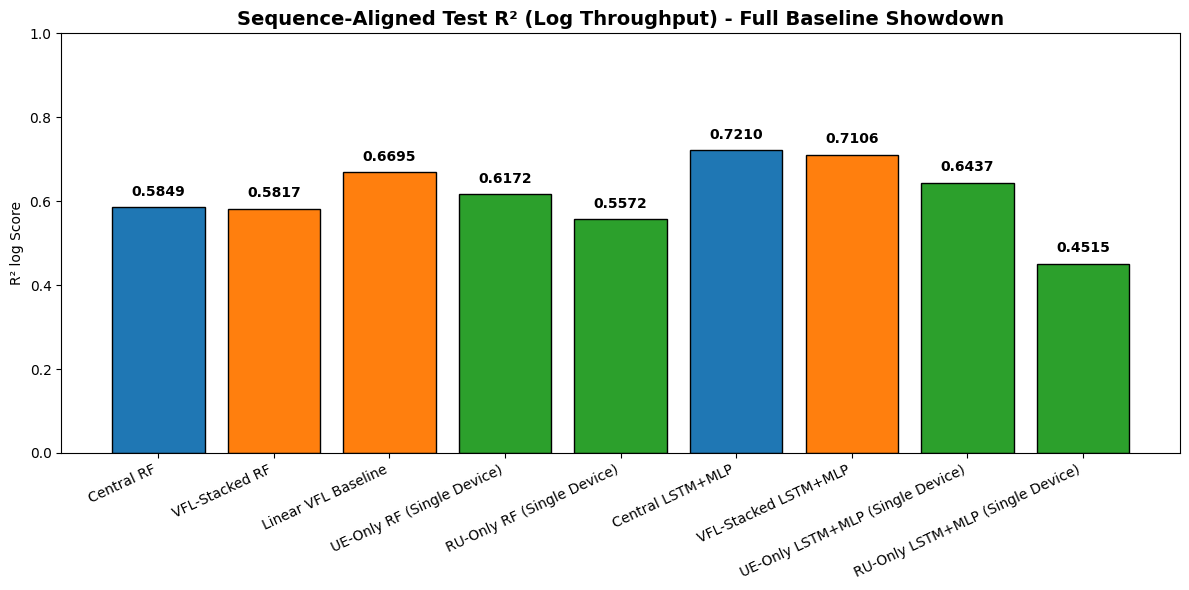

In [57]:
# =====================================================================
# 5. FINAL EVALUATION METRICS DISPLAY
# =====================================================================
predictions = {
    "Central RF": central_rf_pred,
    "VFL-Stacked RF": vfl_stacked_rf_pred,
    "Linear VFL Baseline": vfl_linear_pred,
    "UE-Only RF (Single Device)": ue_vfl_rf_pred,
    "RU-Only RF (Single Device)": ru_vfl_rf_pred,
    "Central LSTM+MLP": dl_cent_pred,
    "VFL-Stacked LSTM+MLP": vfl_dl_pred,
    "UE-Only LSTM+MLP (Single Device)": ue_dl_pred,
    "RU-Only LSTM+MLP (Single Device)": ru_dl_pred,
}

results = {name: get_metrics(y_test, pred) for name, pred in predictions.items()}
result_df = print_metric_table(results)

plot_final_comparison(result_df, path="final_vfl_massive_comparison.png")